# 정기 예금 가입 증대를 위한 데이터 분석 및 예측 모델 제작

작성자 : 신호정

## 1. 요구 사항

은행 마케팅 캠페인 데이터를 분석하여 정기 예금을 가입한 고객의 특성을 파악하고,  
파악된 특성을 기반한 예측 모델을 통해 효과적인 마케팅 전략을 수립하는 것입니다.

## 2. 데이터 분석 (EDA)
2008년 5월 ~ 2010년 11월 까지의 포르투갈 소재 은행 마케팅 켐페인 데이터입니다.  
해당 데이터는 UC Irvine Machine Learning Repository에서 제공하는 Bank Marketing [(링크)](https://archive.ics.uci.edu/dataset/222/bank+marketing) 데이터 입니다.  
여러 데이터 중 2014년 아래 **2.1 데이터 출처** 논문에서 사용된 데이터를 선택하였습니다.

### 2.1 데이터 출처
Moro, S., Cortez, P., & Rita, P. (2014). A Data-Driven Approach to Predict the Success of Bank Telemarketing.  
Decision Support Systems, In press, [(인용)](http://dx.doi.org/10.1016/j.dss.2014.03.001)

### 2.2 원본 데이터 컬럼 설명
| 컬럼명 | 타입 | 설명 |
|:---|:---:|:---:|
| age | int64 | 나이 |
| job | str | 직업 - "admin.","blue-collar","entrepreneur","housemaid","management","retired","self-employed","services","student","technician","unemployed","unknown" |
| marital | str  | 결혼 여부 - "divorced","married","single","unknown" 참고: “이혼”은 이혼 또는 사별을 의미함 |
| education | str  | 교육 수준 - "basic.4y","basic.6y","basic.9y","high.school","illiterate","professional.course","university.degree","unknown" |
| default | str  | 신용 불량 여부 - "no","yes","unknown" |
| housing | str  | 주택 대출 여부 - "no","yes","unknown" |
| loan | str  | 개인 대출 여부 - "no","yes","unknown" |
| contact | str  | 연락 유형 - "cellular","telephone" |
| month | str  | 마지막 연락 월 - "jan", "feb", "mar", ..., "nov", "dec" |
| day_of_week | str  | 마지막 연락 요일 - "mon","tue","wed","thu","fri" |
| duration | int64 | 마지막 연락 지속 시간, 초 단위 - 중요 참고: 이 속성은 출력 대상에 큰 영향을 미칩니다(예: duration=0이면 y="no"). 그러나 통화 전에는 지속 시간을 알 수 없습니다. 또한 통화 종료 후에는 y가 명백히 알려져 있습니다. 따라서 이 입력은 벤치마크 목적으로만 포함되어야 하며, 현실적인 예측 모델을 구축하려는 경우 제외해야 합니다.|
| campaign | int64 | 캠페인 동안 연락 횟수 |
| pdays | int64 | 이전 캠페인 후 지난 일수 - 999는 이전에 연락한 적이 없음을 의미 |
| previous | int64 | 이전 캠페인 동안 연락 횟수 |
| poutcome | str | 이전 캠페인의 결과 - "failure","nonexistent","success" |
| emp.var.rate | float64 | 고용 변동률 |
| cons.price.idx | float64 | 소비자 물가지수 |
| cons.conf.idx | float64 | 소비자 신뢰지수 |
| euribor3m | float64 | 3개월 EURIBOR 금리 |
| nr.employed | int64 | 고용자 수 |
| y | str | 정기 예금 가입 여부 ('y' 또는 'no'로 표시됨) |

### 2.3 분석 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.font_manager as fm
import seaborn as sns

FONT_PATH = 'NanumGothic.ttf'

column_name_mapping = {
    'age': '나이',
    'job': '직업',
    'marital': '결혼_여부',
    'education': '교육_수준',
    'default': '신용_불량_여부',
    'housing': '주택_대출_여부',
    'loan': '개인_대출_여부',
    'contact': '연락_방식',
    'month': '마지막_연락_월',
    'day_of_week': '마지막_연락_요일',
    'duration': '마지막_연락_지속_시간',
    'campaign': '캠페인_연락_횟수',
    'pdays': '과거_캠페인_이후_경과_일수',
    'previous': '과거_캠페인_동안_연락_횟수',
    'poutcome': '과거_캠페인_결과',
    'emp.var.rate': '고용_변동률',
    'cons.price.idx': '소비자_물가_지수',
    'cons.conf.idx': '소비자_신뢰_지수',
    'euribor3m': '3개월_EURIBOR_금리',
    'nr.employed': '고용자_수',
    'y': '예금_가입_여부'
}

job_column_mapping = {
    'admin.': '관리자',
    'blue-collar': '육체_노동자',
    'entrepreneur': '사업가',
    'housemaid': '가정부',
    'management': '관리직',
    'retired': '은퇴자',
    'self-employed': '자영업자',
    'services': '서비스직',
    'student': '학생',
    'technician': '기술자',
    'unemployed': '실업자',
    'unknown': '알_수_없음'
}

marital_column_mapping = {
    'divorced': '이혼',
    'married': '기혼',
    'single': '미혼',
    'unknown': '알_수_없음'
}

education_column_mapping = {
    'basic.4y': '초등4년',
    'basic.6y': '초등6년',
    'basic.9y': '초등9년',
    'high.school': '고등학교',
    'professional.course': '전문_과정',
    'university.degree': '대학_학위',
    'unknown': '알_수_없음'
}

default_column_mapping = {
    'no': '아니오',
    'yes': '예',
    'unknown': '알_수_없음'
}

housing_column_mapping = {
    'no': '아니오',
    'yes': '예',
    'unknown': '알_수_없음'
}

loan_column_mapping = {
    'no': '아니오',
    'yes': '예',
    'unknown': '알_수_없음'
}

contact_column_mapping = {
    'cellular': '휴대전화',
    'telephone': '유선전화',
    'unknown': '알_수_없음'
}

month_column_mapping = {
    'jan': '1월',
    'feb': '2월',
    'mar': '3월',
    'apr': '4월',
    'may': '5월',
    'jun': '6월',
    'jul': '7월',
    'aug': '8월',
    'sep': '9월',
    'oct': '10월',
    'nov': '11월',
    'dec': '12월'
}

day_of_week_column_mapping = {
    'mon': '월요일',
    'tue': '화요일',
    'wed': '수요일',
    'thu': '목요일',
    'fri': '금요일'
}

poutcome_column_mapping = {
    'failure': '실패',
    'success': '성공',
    'nonexistent': '알_수_없음'
}

y_column_mapping = {
    'no': '아니오',
    'yes': '예'
}

def initialize():
    fm.fontManager.addfont(FONT_PATH)
    
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    
    df = pd.read_csv('bank-additional-full.csv', sep=';')

    df.rename(columns=column_name_mapping, inplace=True)
    
    df['직업'] = df['직업'].map(job_column_mapping)
    df['결혼_여부'] = df['결혼_여부'].map(marital_column_mapping)
    df['교육_수준'] = df['교육_수준'].map(education_column_mapping)
    df['신용_불량_여부'] = df['신용_불량_여부'].map(default_column_mapping)
    df['주택_대출_여부'] = df['주택_대출_여부'].map(housing_column_mapping)
    df['개인_대출_여부'] = df['개인_대출_여부'].map(loan_column_mapping)
    df['연락_방식'] = df['연락_방식'].map(contact_column_mapping)
    df['마지막_연락_월'] = df['마지막_연락_월'].map(month_column_mapping)
    df['마지막_연락_요일'] = df['마지막_연락_요일'].map(day_of_week_column_mapping)
    df['과거_캠페인_결과'] = df['과거_캠페인_결과'].map(poutcome_column_mapping)
    df['예금_가입_여부'] = df['예금_가입_여부'].map(y_column_mapping)
    
    return df

origin_df = initialize()

### 2.4 변환 데이터 컬럼 설명
데이터의 해석을 용이하게 진행하기 위해 컬럼과 컬럼 내의 분류 값들에 대한 한글 매핑을 진행하였습니다.

| 컬럼명 | 타입 | 설명 |
|:---|:---:|:---:|
| 나이 | int64 | - |
| 직업 | str | '행정직','노동직','창업자','가정부','관리직','퇴직자','자영업자','서비스직','학생','기술직','실업자','미상' |
| 결혼 여부 | str  | '이혼','기혼','미혼','모름' 참고: '이혼'은 이혼 또는 사별을 의미함 |
| 교육 수준 | str  | '초등4년','초등6년','초등9년','고등학교','문맹','전문과정','대학졸업','알 수 없음' |
| 신용 불량 여부 | str  | '예','아니오','알 수 없음' |
| 주택 대출 여부 | str  | '예','아니오','알 수 없음' |
| 개인 대출 여부 | str  | '예','아니오','알 수 없음' |
| 연락 방식 | str  | '휴대전화','유선전화' |
| 마지막 연락 월 | str  | '1월', '2월', '3월', ..., '11월', '12월' |
| 마지막 연락 요일 | str  | '월','화','수','목','금' |
| 마지막 연락 지속 시간 | int64 | 마지막 연락 지속 시간, 초 단위 - 중요 참고: 이 속성은 출력 대상에 큰 영향을 미칩니다(예: duration=0이면 y="no"). 그러나 통화 전에는 지속 시간을 알 수 없습니다. 또한 통화 종료 후에는 y가 명백히 알려져 있습니다. 따라서 이 입력은 벤치마크 목적으로만 포함되어야 하며, 현실적인 예측 모델을 구축하려는 경우 제외해야 합니다.|
| 캠페인 동안 연락 횟수 | int64 | - |
| 과거 캠페인 후 지난 일수 | int64 | 999는 이전에 연락한 적이 없음을 의미 |
| 과거 캠페인 동안 연락 횟수 | int64 | - |
| 과거 캠페인의 결과 | str | '실패','존재하지 않음', '성공' |
| 고용 변동률  | float64 | - |
| 소비자 물가지수 | float64 | - |
| 소비자 신뢰지수 | float64 | - |
| 3개월 EURIBOR 금리 | float64 | - |
| 고용자 수 | int64 | - |
| 예금 가입 여부 | str | 'y' 또는 'no'로 표시됨 |

### 2.5 데이터 기본 통계

데이터 전반의 특성을 파악하고, 이후 분석에 필요한 계획을 수립합니다.

In [2]:
origin_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   나이               41188 non-null  int64  
 1   직업               41188 non-null  str    
 2   결혼_여부            41188 non-null  str    
 3   교육_수준            41170 non-null  str    
 4   신용_불량_여부         41188 non-null  str    
 5   주택_대출_여부         41188 non-null  str    
 6   개인_대출_여부         41188 non-null  str    
 7   연락_방식            41188 non-null  str    
 8   마지막_연락_월         41188 non-null  str    
 9   마지막_연락_요일        41188 non-null  str    
 10  마지막_연락_지속_시간     41188 non-null  int64  
 11  캠페인_연락_횟수        41188 non-null  int64  
 12  과거_캠페인_이후_경과_일수  41188 non-null  int64  
 13  과거_캠페인_동안_연락_횟수  41188 non-null  int64  
 14  과거_캠페인_결과        41188 non-null  str    
 15  고용_변동률           41188 non-null  float64
 16  소비자_물가_지수        41188 non-null  float64
 17  소비자_신뢰_지수        41188 

교육 수준에서 18건의 결측치가 확인됩니다. 이 결측치를 '알 수 없음' 으로 대체합니다.

In [3]:
origin_df['교육_수준'] = origin_df['교육_수준'].fillna('알_수_없음')
origin_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   나이               41188 non-null  int64  
 1   직업               41188 non-null  str    
 2   결혼_여부            41188 non-null  str    
 3   교육_수준            41188 non-null  str    
 4   신용_불량_여부         41188 non-null  str    
 5   주택_대출_여부         41188 non-null  str    
 6   개인_대출_여부         41188 non-null  str    
 7   연락_방식            41188 non-null  str    
 8   마지막_연락_월         41188 non-null  str    
 9   마지막_연락_요일        41188 non-null  str    
 10  마지막_연락_지속_시간     41188 non-null  int64  
 11  캠페인_연락_횟수        41188 non-null  int64  
 12  과거_캠페인_이후_경과_일수  41188 non-null  int64  
 13  과거_캠페인_동안_연락_횟수  41188 non-null  int64  
 14  과거_캠페인_결과        41188 non-null  str    
 15  고용_변동률           41188 non-null  float64
 16  소비자_물가_지수        41188 non-null  float64
 17  소비자_신뢰_지수        41188 

In [30]:
origin_df.duplicated().sum()

np.int64(12)

12건의 중복데이터가 발견되었습니다. 이 데이터들은 삭제처리하여 분석 정밀도를 증가시키겠습니다.

In [31]:
origin_df = origin_df.drop_duplicates()

In [32]:
origin_df.describe()

,나이,마지막_연락_지속_시간,캠페인_연락_횟수,과거_캠페인_이후_경과_일수,과거_캠페인_동안_연락_횟수,고용_변동률,소비자_물가_지수,소비자_신뢰_지수,3개월_EURIBOR_금리,고용자_수
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


- 나이 : 17세에서 98세까지의 고객이 존재합니다. 평균 나이는 약 40세입니다.

- 마지막 연락 지속 시간 : 4918시간부터 0시간까지 전체적으로 큰 표준편차(259.2)를 보입니다. 평균 시간은 약 258시간입니다.

- 캠페인 경과 일수 : 999가 시도하지 않은 값이기 때문에, 이 부분은 조건을 걸어 따로 살펴야 합니다.

- 과거 캠페인 동안 연락 횟수 : 0회부터 최대 7회까지의 값이 관측됩니다.  
    평균적으로 0.17회의 연락이 이루어진 것으로 보아, 연락 비율이 낮음을 확인 할 수 있습니다.

- 고용 변동률 : 이전 시점 대비 고용 규모가 얼마나 변했는지를 나타내는 지표입니다.  
    조사해보니 일반적인 계산식은 고용변동률 = ((현재고용자수 − 이전고용자수) / 이전고용자수) ​× 100 이라 합니다.
    양수일수록 고용이 증가하며, 음수일때는 반대로 고용이 감소된다는 의미입니다.
    1.4에서 -3.4까지 다양한 수치를 보이고 있으며, 평균은 0.08로 거의 정체되어 있습니다.

- 소비자 물가 지수 : CPI = (현재소비자물가 / 기준연도소비자물가) ​× 100 으로 구합니다.  
    기준 연도의 물가가 100 일 때, 100 이하면 물가 하락, 100 이상이면 물가 상승입니다.  
    CPI 가 상승하면 경제적으로 인플레이션 압력이 있으며, 하락하면 디플레이션 또는 수요가 약화되었다는 의미입니다.  
    즉 정기 예금에 긍정적으로 작용하는 인자중 하나는 CPI 상승이며,  
    이것이 금리 상승으로 이어져야 예금 가입의 상승으로로 이어집니다.  
    데이터 상에서는 평균적으로 소비지 물가 지수(CPI)가 하락세가 이어진 것으로 확인됩니다.

- 소비자 신뢰 지수 : 가계가 현재 경제 상황과 향후 경제 전망을 얼마나 낙관적으로 보는지를 측정하는 지표입니다.  
    0을 기준으로 양수일때 소비자 심리 낙관, 음수일 때 소비자 심리 비관으로 나타납니다.  
    데이터 상에서는 아주 강한 소비자 심리 비관의 성향이 관찰되는데, 이는 이 때가 **글로벌 금융 위기의 침체 여파**로 해석 할 수 있습니다.

- 3개월 EURIBOR 금리 : 유럽 은행 간 단기 자금 거래 금리 입니다. 대표적인 단기 기준금리 지표 입니다.  
    2.0을 기준으로 낮을수록 완화 정책, 높을수록 긴축 정책으로 해석합니다.  
    해당 지표가 상승할 수록 예금 상품 가입이 증가하는 경향을 보입니다.  
    데이터 상에서는 5% 대의 고금리였다가 글로벌 금융 위기를 겪으면서 0.063로 저금리로 전환되는 모습이 보입니다.

- 고용자 수 : 특정 시점에 경제 전체에서 고용된 사람의 수(천 단위)를 의미합니다.  
    값이 증가할수록 고용이 증가하고 경기가 확장되며, 반대의 경우 경기가 침체되어 고용이 감소합니다.  
    전체 고용자수가 5228에서 4963까지 큰 변화를 보이고 있습니다.

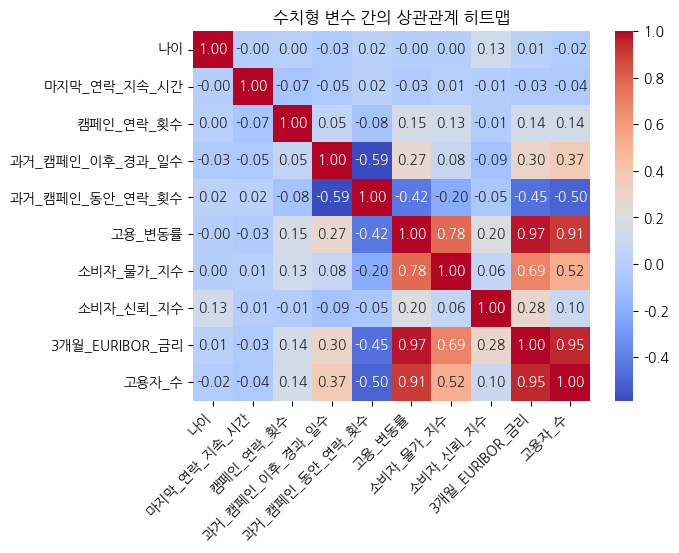

In [5]:
# 수치형 변수 간의 상관관계 히트맵

seq = origin_df.select_dtypes(include='number')
corr = seq.corr(method='pearson')

ax = sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right',
    fontsize=10
)
plt.title('수치형 변수 간의 상관관계 히트맵')
plt.show()

- 나이 : 다른 변수들과의 연관 관계가 거의 없습니다.

- 마지막 연락 지속 시간 : 이 변수도 연관 관계가 관찰되지 않습니다.

- 캠페인 연락 횟수 : 고용 변동률, 소비자 물가 지수, 3개월 EURIBOR 금리, 고용자 수에서 미약한 연관 관계가 관찰됩니다

- 과거 캠페인 이후 경과 일수 : 고용 변동률, 소비자 물가 지수, 3개월 EURIBOR 금리, 고용자 수에서 어느 정도의 연관 관계가 관찰됩니다.  
    또한 과거 캠페인 동안 연락 횟수와는 강한 반대 관계가 성립합니다.

- 과거 캠페인 동안 연락 횟수 : 과거 캠페인 이후 경과 일수, 고용 변동률, 소비자 물가 지수, 3개월 EURIBOR 금리, 고용자 수에서  
    강한 반대 관계가 관찰됩니다.

- 고용 변동률 : 소비자 물가 지수에서 강한 연관 관계를 보이며  
특히 3개월 EURIBOR 금리, 고용자 수에서 대단히 강한 연관 관계가 관찰됩니다.  
또한 소비자 신뢰 지수도 약간의 연관 관계를 보입니다.

- 소비자 물가 지수 : 고용 변동률, 3개월 EURIBOR 금리, 고용자 수에서 연관 관계가 관찰됩니다.

- 소비자 신뢰 지수 : 고용 변동률에 약한 연관 관계가 보입니다.

- 3개월 EURIBOR 금리 : 과거 캠페인 동안 연락 횟수와는 음의 관계가 뚜렷하게 관찰되며,  
캠페인 연락 횟수, 과거 캠페인 이후 경과 일수, 소비자 신뢰 지수 와는 약간의 연관 관계가 관찰됩니다.
소비자 물가 지수와는 강한 연관 관계가 관찰되며,
고용 변동률, 고용자 수와는 아주 강한 연관 관계를 관찰 할 수 있습니다.

- 고용자 수 : 과거 캠페인 동안 연락 횟수와는 음의 관계가 뚜렷하게 관찰되며,  
캠페인 연락 횟수, 과거 캠페인 이후 경과 일수, 소비자 신뢰 지수 와는 약간의 연관 관계가 관찰됩니다.
소비자 물가 지수와는 확실한 연관 관계가 관찰되며,
고용 변동률, 3개월 EURIBOR 금리와는 아주 강한 연관 관계를 관찰 할 수 있습니다.

#### <기본 통계 종합 해석>
1. 교육 수준에서 18건의 결측치를 발견하였으며, 이것을 '알 수 없음'으로 처리하였습니다.

2. 고용 변동률, 3개월 EURIBOR 금리, 고용자 수는 서로 다른 수집 경로를 가지지만 아주 강한 상관관계를 보이고 있습니다.  
    따라서 이 데이터를 다중공선성 문제없이 분석하기 위해서는 선형 모델보다는 트리 모델,  
    그 중에서 **LightGBM이나 XGBoost 를 사용**하는 것이 옳다고 판단됩니다.

3. 마지막 연락 지속시간은 데이터 컬럼 소개에서 말하는 것처럼, 모델 학습에서는 제외 예정입니다만  
    아주 강한 편차를 보이는 이유를 추가로 해석해야 할 필요는 있습니다: [2.6.5 항목 참조](####2.6.5-마지막-연락-지속-시간-duration-은-왜-제외해야-할까)

### 2.6 데이터 주제별 분석

이제 기본 통계로 명확하게 확인되지 않은 컬럼 별 상세 분석을 진행합니다.

#### 2.6.1 목표 변수 : '예금 가입 여부' 분석

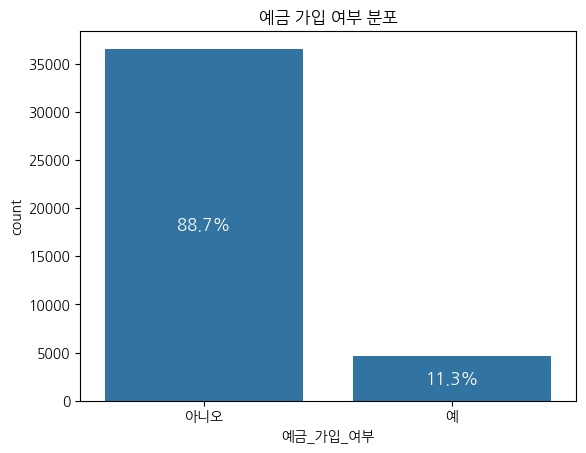

In [46]:
ax = sns.countplot(data=origin_df, x='예금_가입_여부')
plt.title('예금 가입 여부 분포')

total = len(origin_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() / 2
    ax.annotate(percentage, (x, y), ha='center', va='center', fontsize=12, color='white', fontweight='bold')
    
plt.show()

가입한 고객의 비율이 11.3%로 클래스 불균형 데이터로 확인됩니다.  
따라서 정확도(Accuracy)는 가입한 고객을 제대로 맞추지 못해도 높은 수치가 기록되므로(90%) 의미없는 평가 지표가 됩니다.

#### 2.6.2 어떤 사람의 가입 비율이 높을까?

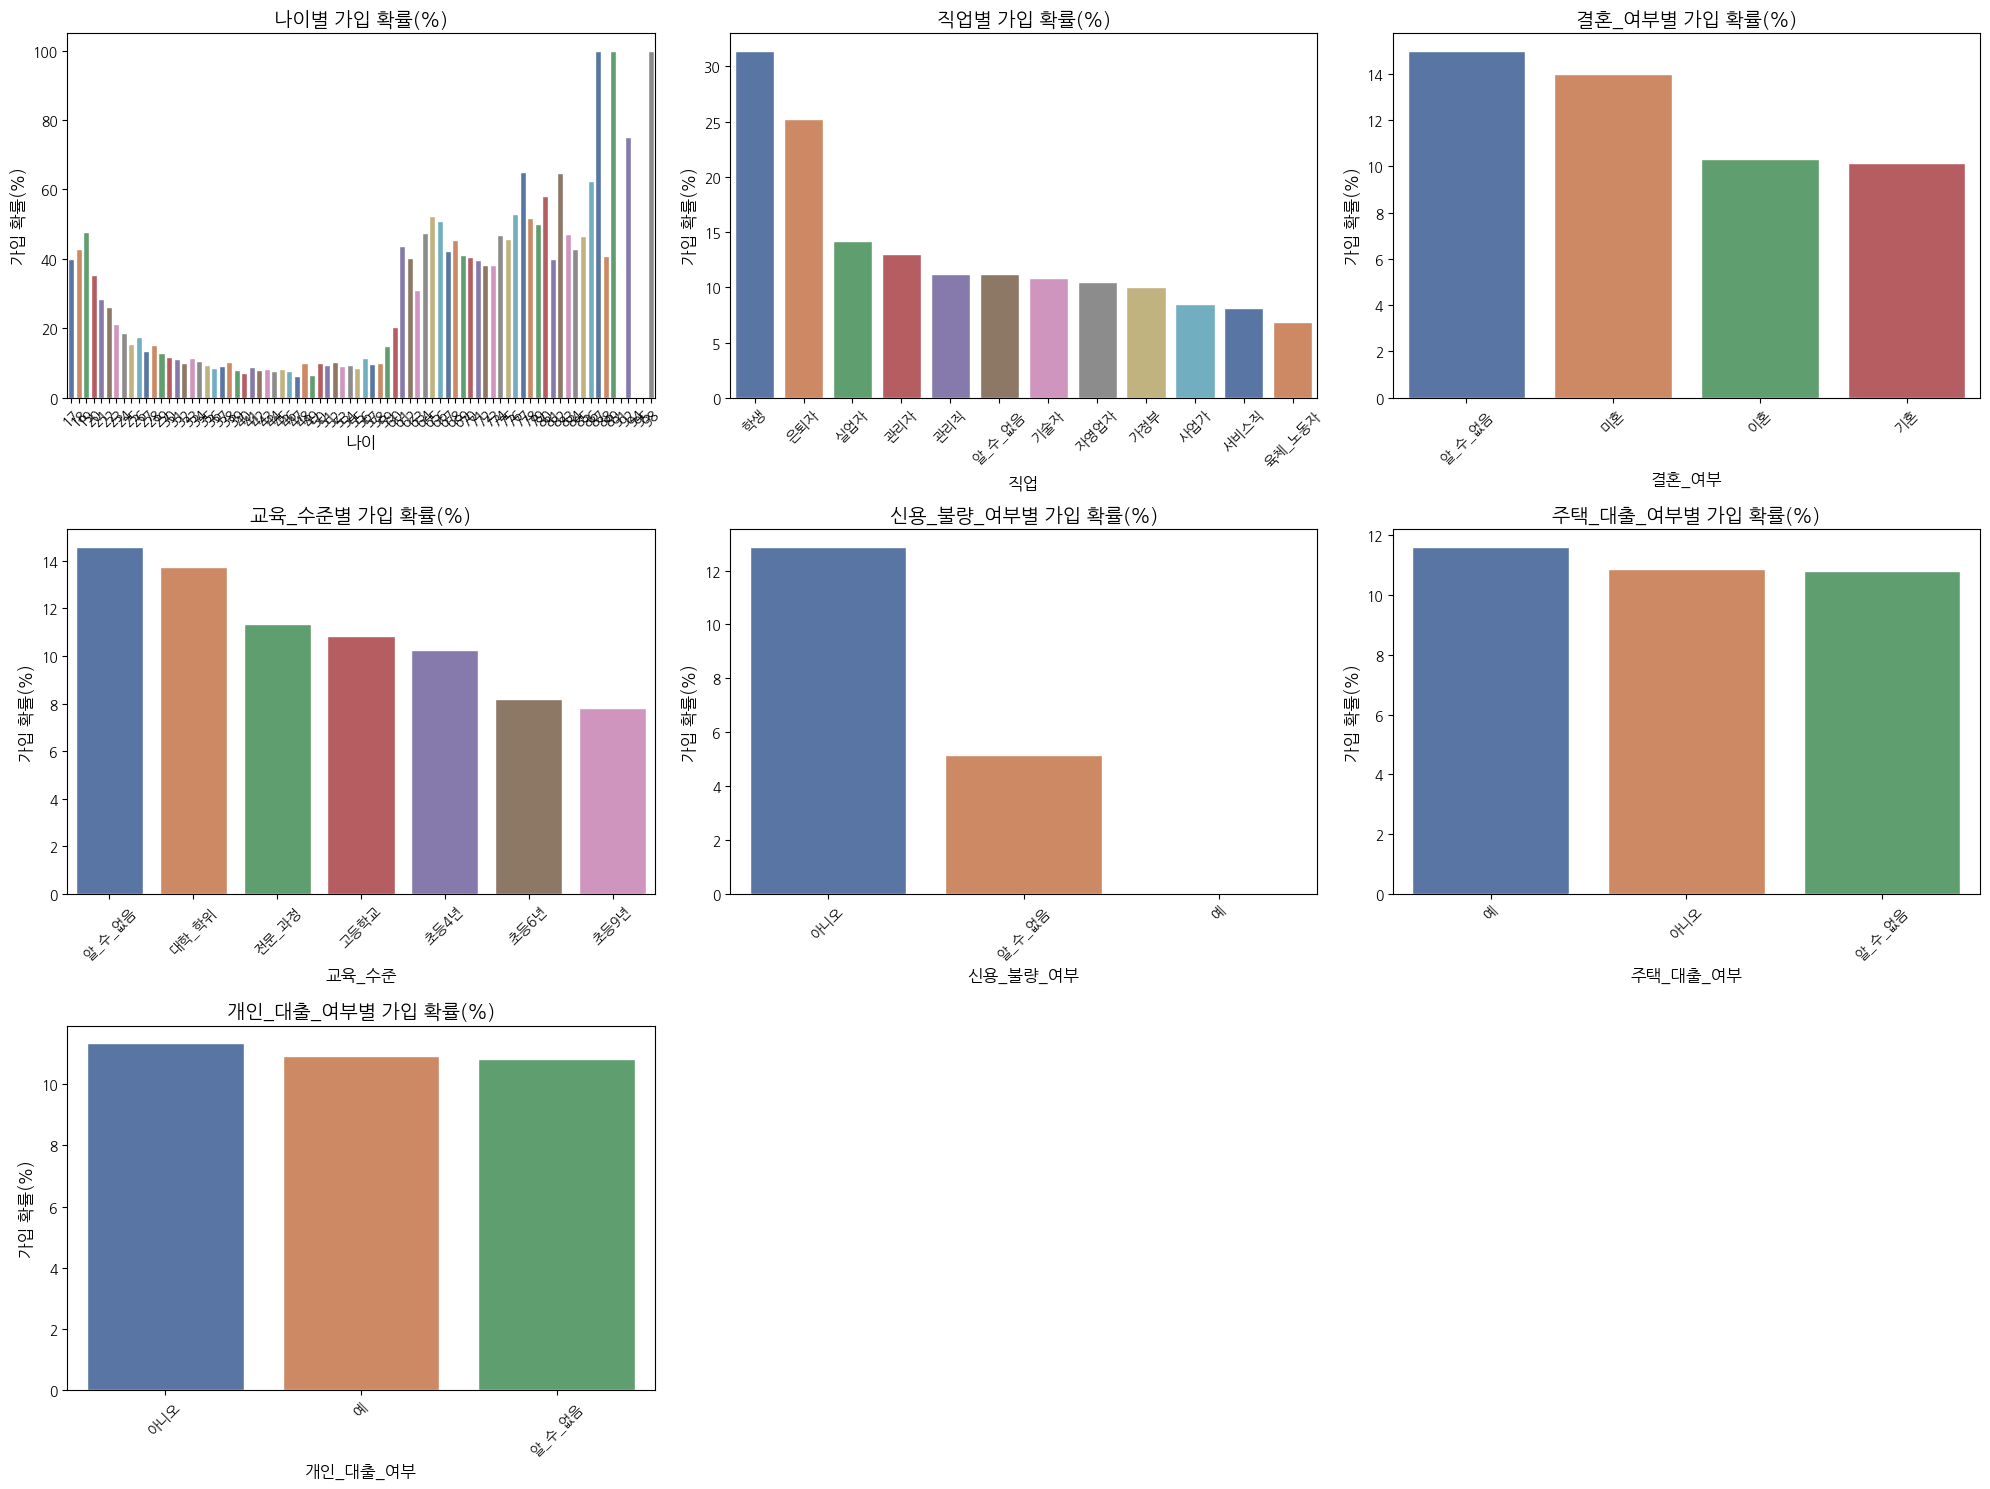

In [6]:
def analyze_conversion_rates(target_df):
    df = target_df.copy()
    
    df['가입_여부_수치'] = df['예금_가입_여부'].apply(lambda x: 1 if x == '예' else 0)
    
    features = ['나이', '직업', '결혼_여부', '교육_수준',\
                '신용_불량_여부', '주택_대출_여부', '개인_대출_여부']
    
    plt.figure(figsize=(20, 15))
    
    for i, feature in enumerate(features, 1):
        plt.subplot(3, 3, i)
        
        conversion_rate = df.groupby(feature)['가입_여부_수치'].mean() * 100
        conversion_rate = conversion_rate.reset_index()
        conversion_rate.columns = [feature, '가입 확률(%)']
        
        conversion_rate = conversion_rate.sort_values(by='가입 확률(%)', ascending=False)
        
        sns.barplot(x=feature, y='가입 확률(%)', data=conversion_rate, palette='deep', edgecolor='w', hue=feature, legend=False)
        
        plt.title(f'{feature}별 가입 확률(%)', fontsize=14)
        plt.xlabel(feature, fontsize=12)
        plt.ylabel('가입 확률(%)', fontsize=12)
        plt.xticks(rotation=45)
        
    plt.tight_layout()
    plt.show()

analyze_conversion_rates(origin_df)

그래프는 개인 정보 컬럼이라 할 수 있는  
'나이', '직업', '결혼 여부', '교육 수준', '신용 불량 여부', '주택 대출 여부', '개인 대출 여부' 에 포함된  
데이터 값들을 표기한 것입니다.  

- 나이 : 60대 이상에서 상당한 비중을 차지하는 것으로 조사되었습니다. 의외로 10대도 비중을 차지하는 것으로 확인됩니다.  
    이것은 10대의 경우 공과금 등의 가계 부담이 적기 때문에 여유자금을 투자할 여력이 있기 때문으로 보이고,  
    60대의 경우 은퇴한 이후 노후 자금을 안정적으로 관리하기 위한 수단으로 정기예금을 선호하는 것으로 풀이 할 수 있습니다.

- 직업 : 나이에서 확인 할 수 있었던 것처럼, 학생과 은퇴자가 높은 비중을 차지하고 있습니다.

- 결혼 여부 : 결혼하지 않은 10대와 독신으로 지내어 가계비에 큰 부담이 없는 사람들이 주로 가입을 하는 추세가 보입니다.

- 교육 수준 : 교육 수준이 높을수록 가입률이 높습니다.

- 신용 불량 여부 : 당연하게도 신용 불량 상태에서는 은행 계좌가 부담스럽지요.

- 주택 대출과 개인 대출 여부 : 대출이 있는 상황에서도 가입을 하는 추세가 있어 의외였습니다.

##### <중간 정리>
가계비의 부담이 없는 학생이나 은퇴자가 생활에 여유가 있는 상황에서 가입할 확률이 높다고 볼 수 있습니다.

#### 2.6.3 휴대전화와 유선전화의 가입률은 차이가 있을까?

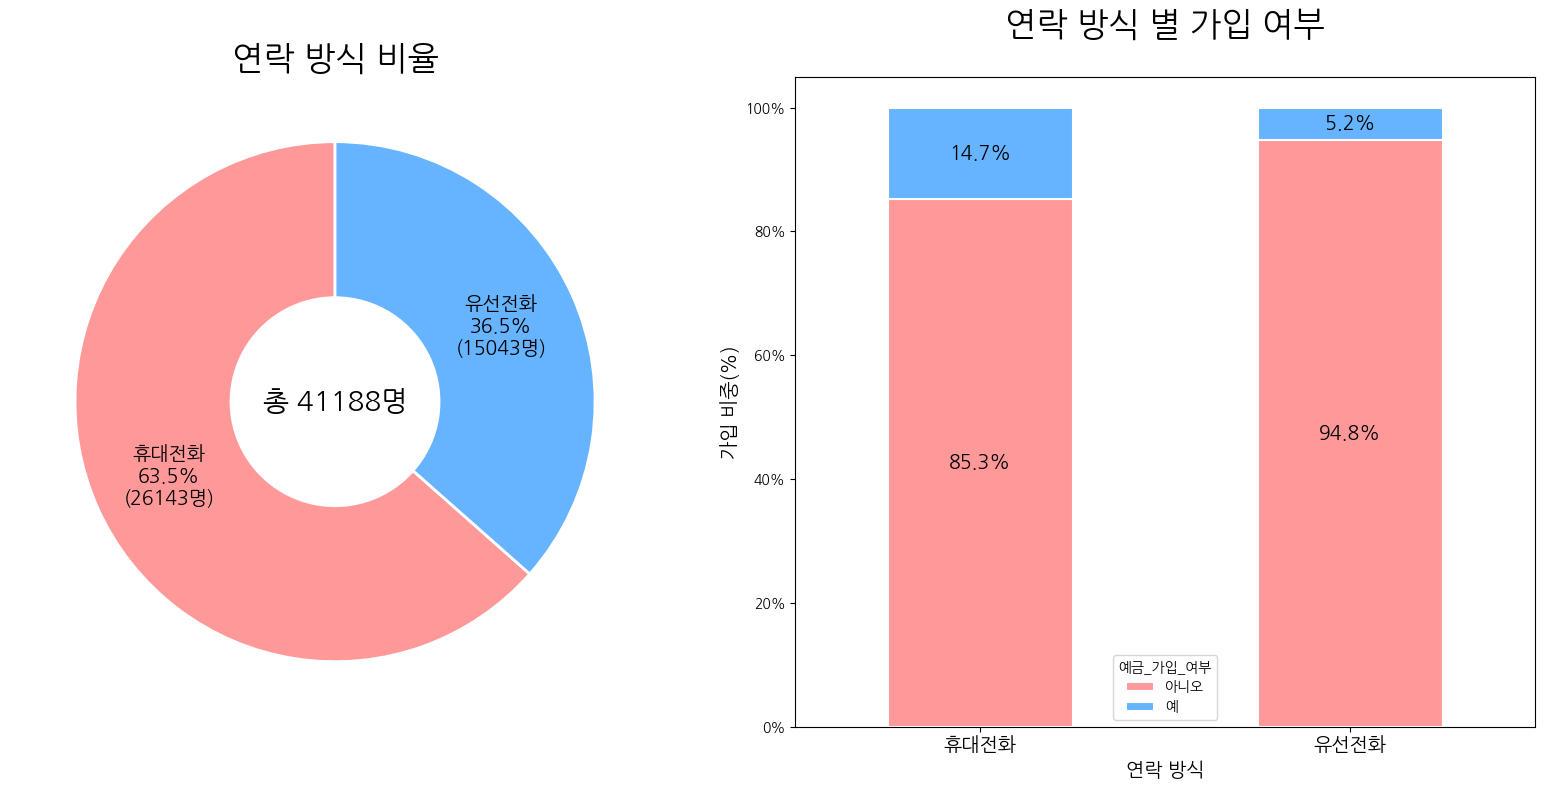

In [7]:
def make_pie_and_bar_graph_for_contact_method(target_df):
    df = target_df.copy()
    
    total_count = len(df)

    cellular_count = len(df[df['연락_방식'] == '휴대전화'])
    telephone_count = len(df[df['연락_방식'] == '유선전화'])

    labels = ['휴대전화', '유선전화']
    sizes = [cellular_count, telephone_count]
    colors = ['#ff9999', '#66b3ff']

    def make_autopct(pct, allvalues):
        absolute = int(pct / 100. * np.sum(allvalues))
        return f'{pct:.1f}%\n({absolute}명)'

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    ax0 = axes[0]

    wedges, texts, autotexts = ax0.pie(sizes,
                                    labels=None,
                                    colors=colors,
                                    autopct=lambda
                                    pct: make_autopct(pct, sizes),
                                    startangle=90,
                                    pctdistance=0.7,
                                    wedgeprops={'width': 0.6, 'edgecolor': 'w', 'linewidth': 2})

    for i, autotext in enumerate(autotexts):
        current_text = autotext.get_text()
        new_text = f"{labels[i]}\n{current_text}"

        autotext.set_text(new_text)
        autotext.set_color('black')
        autotext.set_fontsize(14)

    ax0.text(0, 0,
            f'총 {total_count}명',
            ha='center', va='center', fontsize=20)

    ax0.set_title('연락 방식 비율', fontsize=24)

    ax1 = axes[1]
    
    cross_tab = pd.crosstab(df['연락_방식'], df['예금_가입_여부'])
    cross_tab_div = cross_tab.div(cross_tab.sum(axis=1), axis=0)
    segment_order = ['휴대전화', '유선전화']
    cross_tab_div = cross_tab_div.reindex(segment_order)
    cross_tab_div.plot(kind='bar',
                        stacked=True,
                        ax=ax1, color=['#ff9999', '#66b3ff'],
                        edgecolor='w',
                        linewidth=1.5)
    
    ax1.set_title('연락 방식 별 가입 여부', fontsize=24, pad=30)
    ax1.set_xlabel('연락 방식', fontsize=14 )
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=14)
    ax1.set_ylabel('가입 비중(%)', fontsize=14)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

    for p in ax1.patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        if height > 0:
            ax1.text(x + width / 2, y + height / 2, f'{height:.1%}', ha='center', va='center', fontsize=14, color='black')

    plt.tight_layout()
    plt.show()
    
make_pie_and_bar_graph_for_contact_method(origin_df)

연락 방식은 휴대전화가 유선전화보다 63.5 : 36.5 로 1.7배 가량 많으며,  
가입 여부에서도 휴대전화가 14.7 : 5.2 로  2.8배 가량 많은 것을 확인할 수 있습니다.  

수치적으로 확인할 수 있듯이, **마케팅 타겟은 휴대전화로 잡는 것이 효율적인 접근**이라고 할 수 있습니다.

유선전화가 비율과 가입율에서 저조한 것은 그 특성에 있다고 볼 수 있습니다.  
전화를 받기 위해 전화기 근처에 있어야 한다는 조건과 주소에 연동되는 회선 한정이 그 특성들 중 일부입니다.

데이터를 좀 더 분석하여, 가입 확률이 높은 유선전화 고객이 누구인지 확인해보도록 하겠습니다.

#### 2.6.4 유효한 유선 전화 고객층은 누구인가?

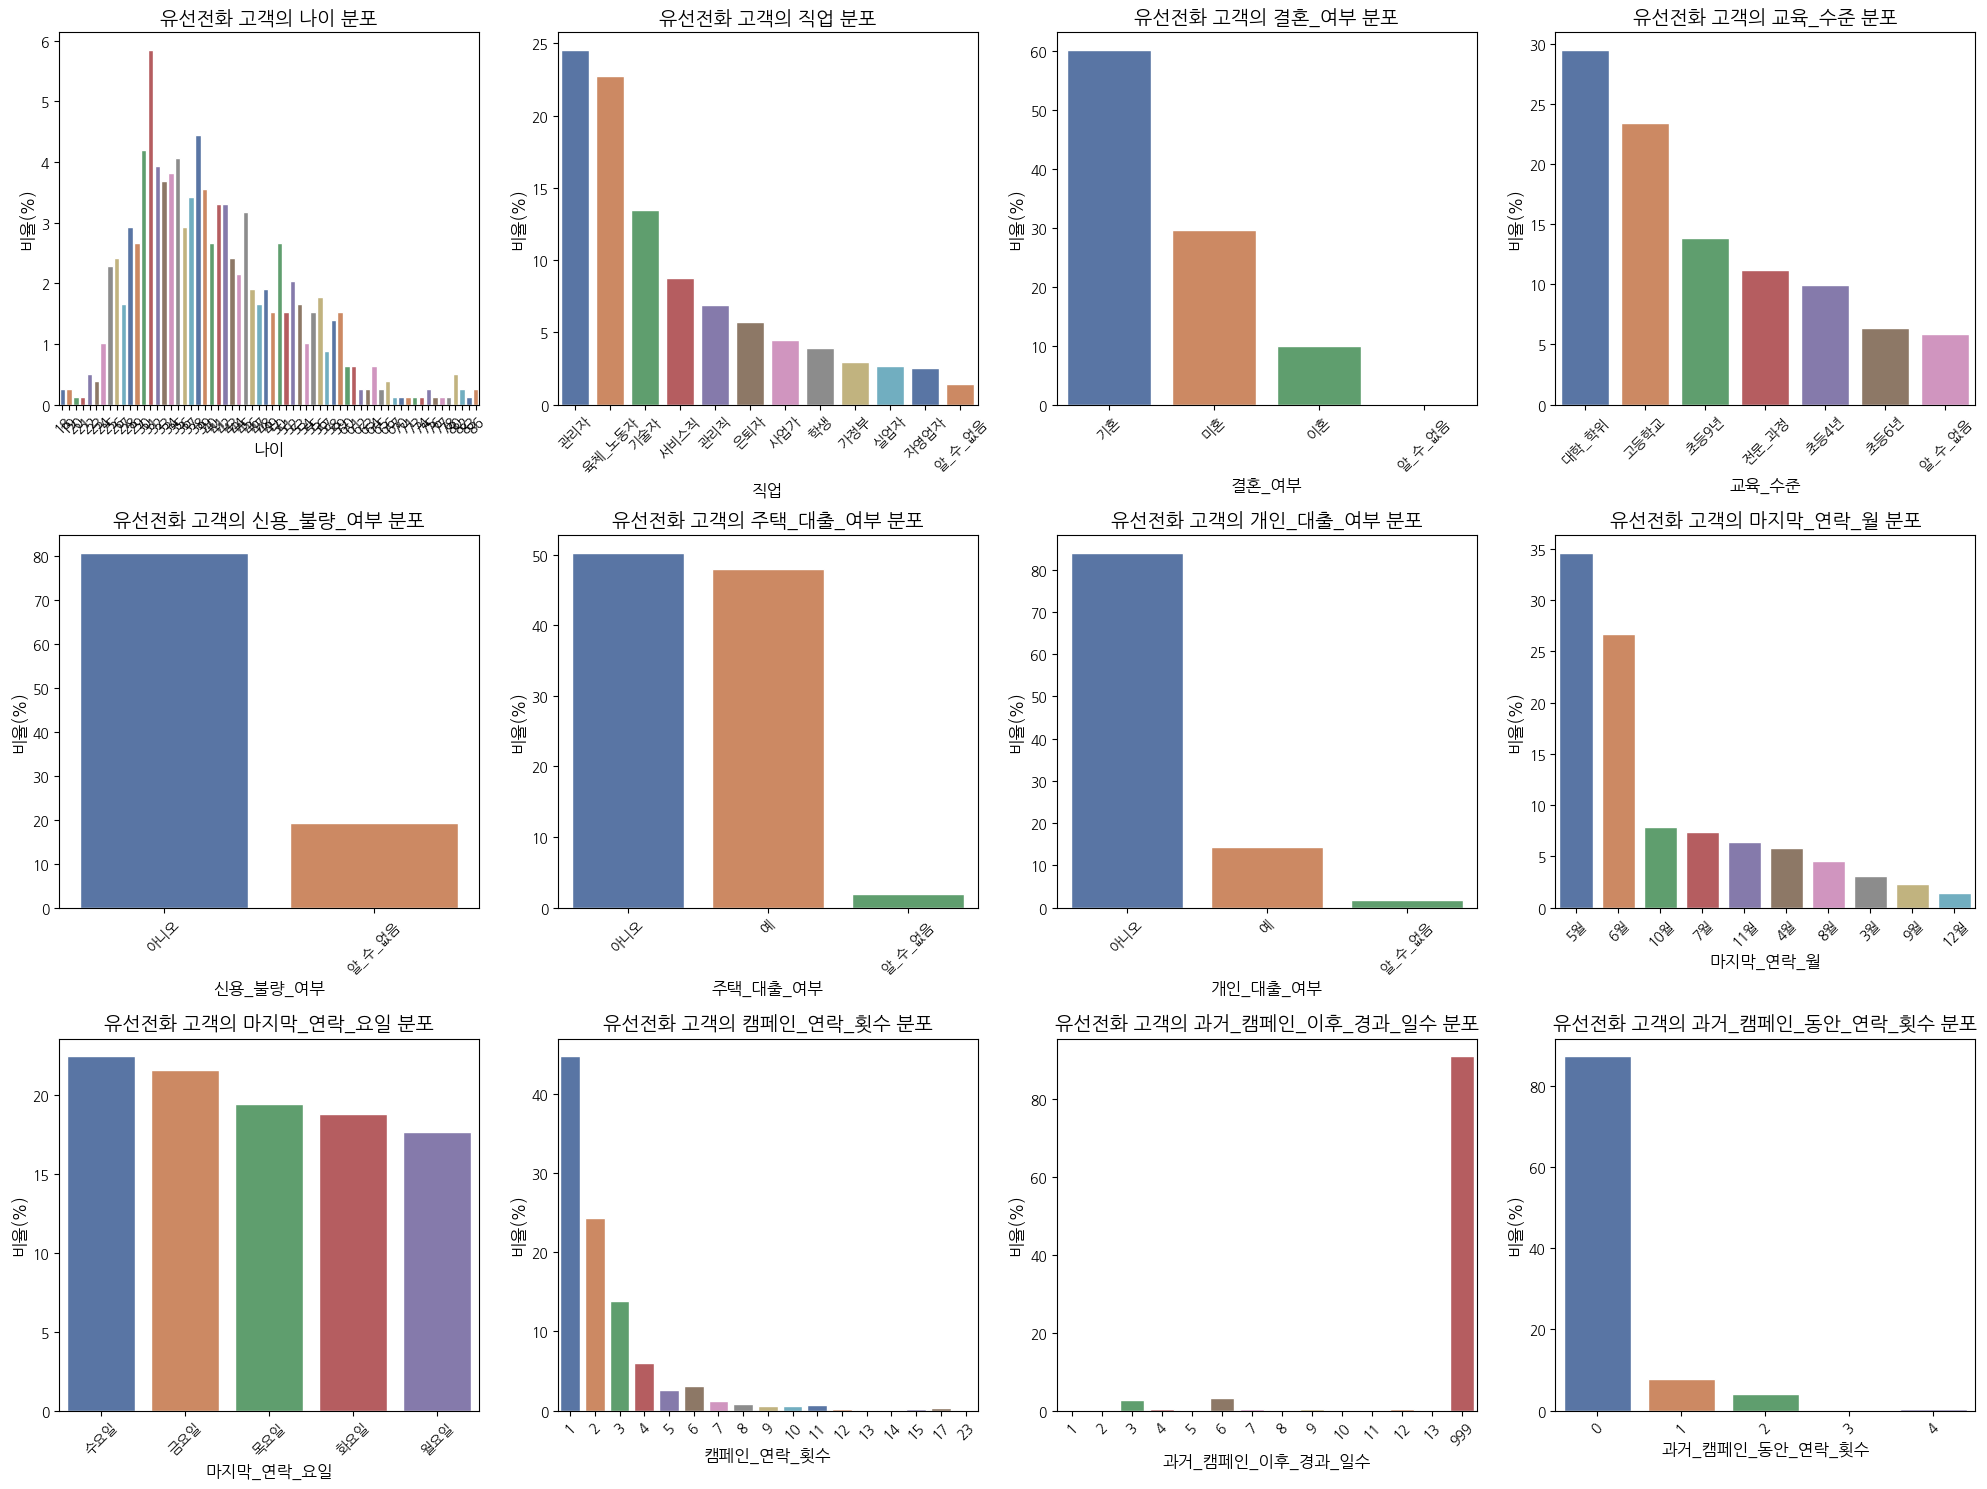

In [8]:
def analyze_telephone_customers(df):
    filtered_df = df[(df['연락_방식'] == '유선전화') & (df['예금_가입_여부'] == '예')]
    
    features = ['나이', '직업', '결혼_여부', '교육_수준',\
                '신용_불량_여부', '주택_대출_여부', '개인_대출_여부',\
                '마지막_연락_월', '마지막_연락_요일', '캠페인_연락_횟수',\
                '과거_캠페인_이후_경과_일수', '과거_캠페인_동안_연락_횟수']
    
    plt.figure(figsize=(20, 15))
    
    for i, feature in enumerate(features, 1):
        plt.subplot(3, 4, i)
        
        prob_data = filtered_df[feature].value_counts(normalize=True) * 100
        prob_data = prob_data.reset_index()
        prob_data.columns = [feature, '비율']
        
        sns.barplot(x=feature, y='비율', data=prob_data, palette='deep', hue=feature, edgecolor='w', legend=False)
        
        plt.title(f'유선전화 고객의 {feature} 분포', fontsize=14)
        plt.xlabel(feature, fontsize=12)
        plt.ylabel('비율(%)', fontsize=12)
        
        plt.xticks(rotation=45)
        
    plt.tight_layout()
    plt.show()

analyze_telephone_customers(origin_df)

그래프는 '유선 전화' 이면서 '가입' 된 고객이라는 조건을 필수로 놓고 도출되었습니다.

- 20 ~ 40대가 유효한 타겟층으로 보입니다.

- 관리자, 육체노동자, 기술자 순으로 가입 성공률이 높습니다

- 기혼일 때, 유선 전화의 특성 상(확실한 거주지) 뚜렷한 가입 성공률을 보입니다.

- 교육 수준이 높을 때 가입률이 높게 집계됩니다

- 생활 필수재인 주택 관련 대출을 빼놓고, 신용과 대출에 여유가 있을 때 가입률이 높습니다.

- 연락 관련된 부분은 은행에서 마케팅을 집행한 시점이 되므로, 통계상 의미는 없다고 봅니다.

- 다만, 가입 권유 전화를 받았을 때 위에서 서술한 조건에 부합되는 사람이면 첫 통화에 가입이 성사되는 비율이 높았습니다.

##### <중간 정리>
경제적 여유가 있는 20 ~ 40대의 기혼 고학력 관리자, 육체노동자가 유력한 유선 전화 마케팅 대상이 됨을 알 수 있습니다.

#### 2.6.5 마지막 연락 지속 시간 (duration) 은 왜 제외해야 할까?

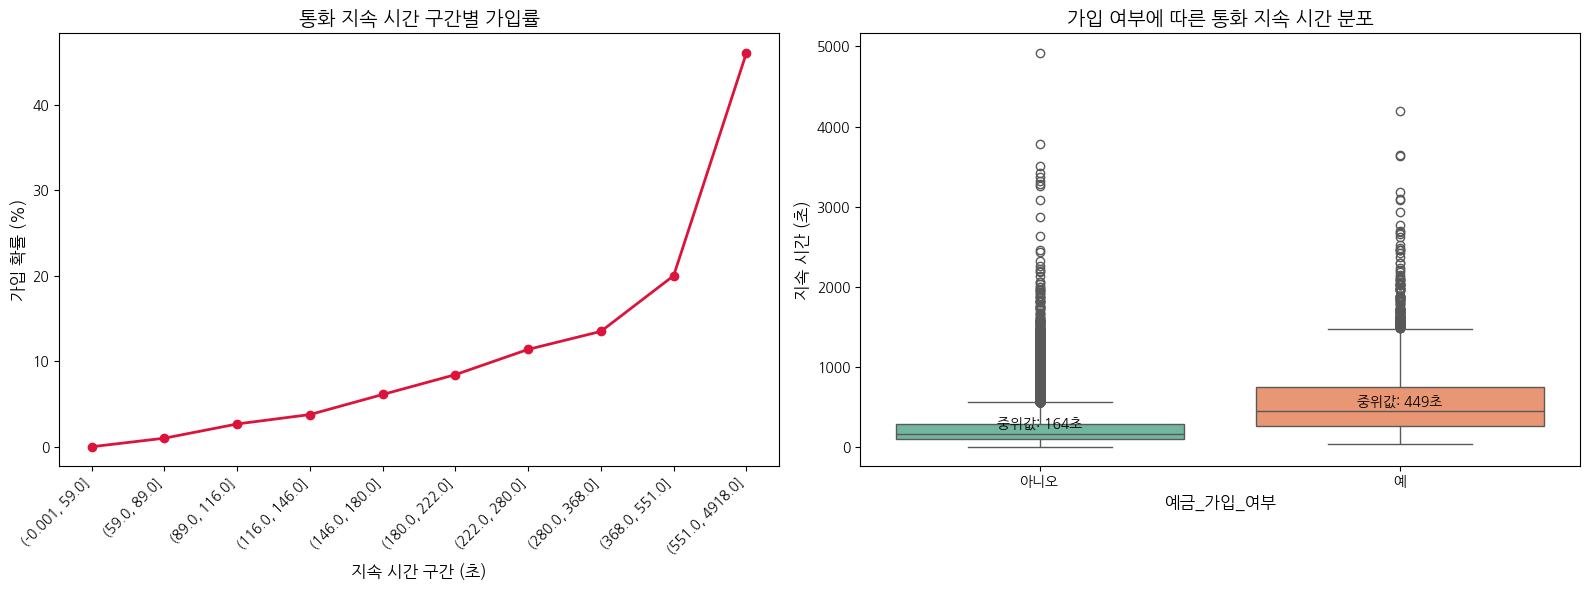

In [9]:
def analyze_duration_leakage(target_df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    df = target_df.copy()
    
    df['가입_여부_수치'] = df['예금_가입_여부'].apply(lambda x: 1 if x == '예' else 0)
    df['지속시간_구간'] = pd.qcut(df['마지막_연락_지속_시간'], q=10, duplicates='drop')
    
    duration_conversion = df.groupby('지속시간_구간')['가입_여부_수치'].mean() * 100
    
    ax0 = axes[0]
    
    ax0.plot(range(len(duration_conversion)), duration_conversion.values, marker='o', linestyle='-', color='crimson', linewidth=2,)
    ax0.set_xticks(range(len(duration_conversion)))
    
    ax0.set_xticklabels([str(interval) for interval in duration_conversion.index], rotation=45, ha='right')
    ax0.set_title('통화 지속 시간 구간별 가입률', fontsize=14)
    ax0.set_xlabel('지속 시간 구간 (초)', fontsize=12)
    ax0.set_ylabel('가입 확률 (%)', fontsize=12)
    
    ax1 = axes[1]
    
    sns.boxplot(x='예금_가입_여부', y='마지막_연락_지속_시간', data=target_df, ax=ax1, palette='Set2', hue='예금_가입_여부', legend=False)
    ax1.set_title('가입 여부에 따른 통화 지속 시간 분포', fontsize=14)
    ax1.set_xlabel('예금_가입_여부', fontsize=12)
    ax1.set_ylabel('지속 시간 (초)', fontsize=12)
    
    order_list = ['아니오', '예']
    
    medians = df.groupby('예금_가입_여부')['마지막_연락_지속_시간'].median()[order_list]
    
    for i, median_val in enumerate(medians):
        ax1.text(i, median_val + 70, f'중위값: {median_val:.0f}초', 
                    horizontalalignment='center', size='medium', color='black', weight='bold')
    
    plt.tight_layout()
    plt.show()

analyze_duration_leakage(origin_df)

왼쪽 그래프는 통화 시간이 길어질수록 가입률이 상승하는 것을 보여주는 그래프며,  
오른쪽 그래프는 예금 가입 여부로 데이터를 나눠서 각자 분포를 박스 플롯으로 그린 그래프입니다.  

먼저 이 수치는 착각하면 안되는 중요한 요소가 있습니다.  
'가입하려는 사람은 통화를 받고서 설명을 듣다가 궁금한 것을 물어보게 되어 있으니 시간이 자연스럽게 길게 잡힌다' 라는 부분입니다.  
즉 왼쪽 그래프에서 통화 시간이 길다는 것은 **'통화를 길게 하면 가입률이 상승한다'** 라고 해석할 것이 아니라  
**'가입을 전제로 놓고 여러 사항을 문의하는 시간이 포함된 것이다'** 라고 보는 것이 옳습니다.  

오른쪽의 박스 플롯은 이 사실을 뒷받침합니다. 박스 플롯의 몸통을 주목하시기 바랍니다.  
예금을 가입하지 않은 사람들의 중위값은 164초인데, 가입한 사람의 중위값은 449초로 기록됩니다.  
즉 예금에 가입할 의사가 없는 사람들은 통화 자체를 길게 하지 않는 성향이 뚜렷하게 확인됩니다.  
이상치가 제법 길게 잡히는 것이 보입니다만, 이 경우에는 조건을 듣다가 최종적으로 거절을 한 **드문** 케이스로 보아야 합니다.  

이와 같은 통화 지속 시간을 예측 모델에 포함하게 되면  
모델은 통화 지속 시간이 길수록 가입에 유리하다라는 잘못된 예측을 내놓을 확률이 무척 높아지게 됩니다.

따라서 통화 지속 시간(duration) 컬럼은 데이터 전처리 과정을 통해 삭제하는 것이 맞습니다.

#### 2.6.6 개인 정보 제공을 꺼리는 사람은 가입에도 소극적일까?

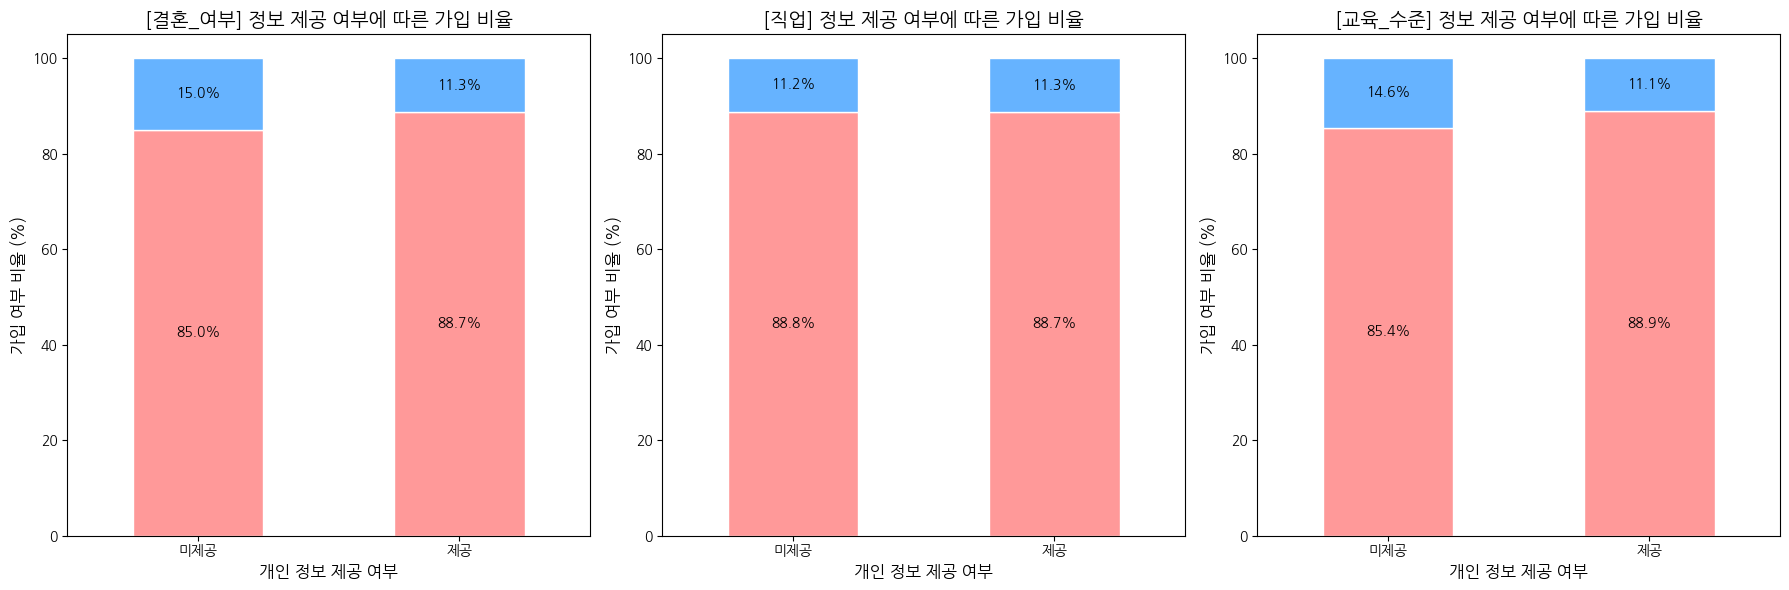

In [10]:
def analyze_unknown_crosstab(target_df):
    df = target_df.copy()
    
    # 비교할 주요 컬럼 리스트
    features = ['결혼_여부', '직업', '교육_수준']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, feature in enumerate(features):
        if feature in df.columns:
            target_ax = axes[i]
            
            info_status = df[feature].apply(lambda x: '미제공' if x in ['알_수_없음'] else '제공')
            
            cross_tab = pd.crosstab(info_status, df['예금_가입_여부'], normalize='index') * 100
            
            cross_tab.plot(kind='bar', stacked=True, ax=target_ax, color=['#ff9999', '#66b3ff'], edgecolor='white')
            
            target_ax.set_title(f'[{feature}] 정보 제공 여부에 따른 가입 비율', fontsize=14)
            target_ax.set_xlabel('개인 정보 제공 여부', fontsize=12)
            target_ax.set_ylabel('가입 여부 비율 (%)', fontsize=12)
            target_ax.tick_params(axis='x', rotation=0)
            
            # 범례 삭제
            target_ax.legend().remove()
            
            for p in target_ax.patches:
                width, height = p.get_width(), p.get_height()
                x, y = p.get_xy() 
                if height > 0:
                    target_ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                                   ha='center', va='center', weight='bold', color='black')
        else:
            target_ax.text(0.5, 0.5, f"'{feature}' 컬럼이 존재하지 않습니다.", ha='center', fontsize=12)
            target_ax.axis('off')
            
    plt.tight_layout()
    plt.show()
    
analyze_unknown_crosstab(origin_df)

왼쪽부터 순서대로 결혼 여부, 직업, 교육 수준에 따른 가입 비율을  
미제공과 제공으로 나누어 비율로 표기한 그래프입니다.

큰 차이를 보이지 않지만,  
개인 정보를 미제공하는 성향의 사람들이 작은 폭이나마 가입률이 높다는 의외의 결과를 보입니다.

이것은 자산 여유가 있는 사람들의 프라이버시 민감도가 높은 것,  
텔레마케팅 도중 가입 의사 전달로 인한 데이터 수집 중단,  
개인 정보 수집 수단의 변경으로 인한 의도치 않은 누락 등으로 설명 할 수 있겠습니다.  

위의 상황을 고려하더다도 **개인 정보 미제공은 특별히 가입의 적극성에 영향을 주지는 않는다** 로 해석해야 할 것으로 보입니다.

#### 2.6.7 가입 재권유는 얼마나 효과적일까?

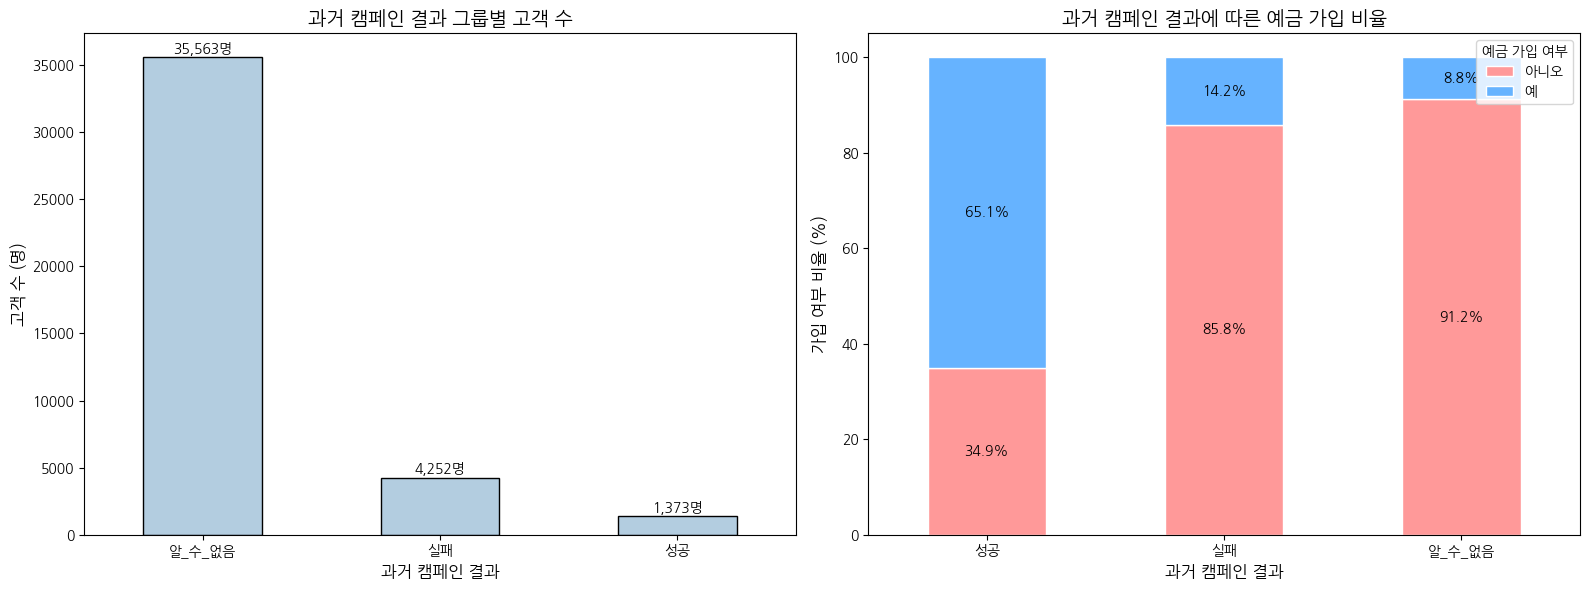

In [11]:
def analyze_poutcome_impact(target_df):
    df = target_df.copy()
    
    col_name = 'poutcome' if 'poutcome' in df.columns else '과거_캠페인_결과'
    
    if col_name not in df.columns:
        print(f"'{col_name}' 컬럼을 찾을 수 없습니다.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    ax0 = axes[0]
    
    poutcome_counts = df[col_name].value_counts()
    poutcome_counts.plot(kind='bar', ax=ax0, color='#b3cde0', edgecolor='black')
    ax0.set_title('과거 캠페인 결과 그룹별 고객 수', fontsize=14)
    ax0.set_xlabel('과거 캠페인 결과', fontsize=12)
    ax0.set_ylabel('고객 수 (명)', fontsize=12)
    ax0.tick_params(axis='x', rotation=0)
    
    # 막대 위에 고객 수 텍스트 표기
    for p in ax0.patches:
        ax0.text(p.get_x() + p.get_width()/2., p.get_height() + 100, 
                     f'{int(p.get_height()):,}명', ha='center', va='bottom')

    cross_tab = pd.crosstab(df[col_name], df['예금_가입_여부'], normalize='index') * 100
    
    order = [val for val in ['nonexistent', 'failure', 'other', 'success'] if val in cross_tab.index]
    if order:
        cross_tab = cross_tab.reindex(order)
    
    ax1 = axes[1]
    
    cross_tab.plot(kind='bar', stacked=True, ax=ax1, color=['#ff9999', '#66b3ff'], edgecolor='white')
    ax1.set_title('과거 캠페인 결과에 따른 예금 가입 비율', fontsize=14)
    ax1.set_xlabel('과거 캠페인 결과', fontsize=12)
    ax1.set_ylabel('가입 여부 비율 (%)', fontsize=12)
    ax1.tick_params(axis='x', rotation=0)
    ax1.legend(title='예금 가입 여부', loc='upper right')

    # 막대 중앙에 % 수치 텍스트 매핑
    for p in ax1.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy() 
        if height > 0: 
            ax1.text(x + width/2, y + height/2, f'{height:.1f}%', 
                     ha='center', va='center', weight='bold', color='black')

    plt.tight_layout()
    plt.show()

analyze_poutcome_impact(origin_df)

좌측 그래프는 과거 가입 권유(캠페인)의 성공 여부 그래프이고,  
우측 그래프는 과거 가입 이력이 있는 고객에게 재권유하였을 때의 성공률을 표기한 그래프입니다.

캠페인을 처음 접하는 사람(86%)의 가입 성공률은 8.8%에 불과하지만  
켐페인을 한번이라도 겪었던 사람들에게는  
과거 실패한 경우(10%)에도 처음 접하는 사람들보다 유의미한 가입 성공률(14.2%)를 보이며,  
성공했던 경우(4%)에는 가입 성공률이 65.1%에 달하여

**캠페인을 진행하는 것은 미래의 잠재 고객을 만들수 있으며, 특히 한번 연락을 받았던 고객들에게는 더 효과적이다**  
라는 결론을 얻을 수 있습니다.

### 2.7 EDA 인사이트 총정리

1. 교육 수준에서 18건의 결측치를 발견하였으며, 이것을 '알 수 없음'으로 처리하였습니다.

2. 12건의 중복 데이터를 삭제하였습니다.

3. 가입한 고객의 비율이 11.3%로 클래스 불균형 데이터로 확인됩니다.  
    따라서 정확도(Accuracy)는 1번 틀려도 높은 수치가 기록되므로 의미없는 평가 지표가 됩니다.

4. 고용 변동률, 3개월 EURIBOR 금리, 고용자 수는 서로 다른 수집 경로를 가지지만 아주 강한 상관관계를 보이고 있습니다.  
    따라서 이 데이터를 다중공선성 문제없이 분석하기 위해서는 선형 모델보다는 트리 모델,  
    그 중에서 **LightGBM이나 XGBoost 를 사용**하는 것이 옳다고 판단됩니다.

5. 마지막 연락 지속시간이 길다는 것은 **'통화를 길게 하면 가입률이 상승한다'** 라고 해석할 것이 아니라  
    **'가입을 전제로 놓고 여러 사항을 문의하는 시간이 포함된 것이다'** 라고 보는 것이 옳습니다.  
    따라서 통화 지속 시간(duration) 컬럼은 데이터 전처리 과정을 통해 **삭제**하는 것이 맞습니다.

6. 가계비의 부담이 없는 학생이나 은퇴자가 생활에 여유가 있는 상황에서 가입할 확률이 높다고 볼 수 있습니다.

7. **마케팅 타겟은 휴대전화로 잡는 것이 효율적인 접근**이라고 할 수 있습니다.

8. 경제적 여유가 있는 20 ~ 40대의 기혼 고학력 관리자, 육체노동자가 유력한 유선 전화 마케팅 대상이 됨을 알 수 있습니다.

9. **개인 정보 미제공은 특별히 가입의 적극성에 영향을 주지는 않는다** 라는 의외의 결과가 나왔습니다.

10. **캠페인을 진행하는 것은 미래의 잠재 고객을 만들수 있으며, 특히 한번 연락을 받았던 고객들에게는 더 효과적이다**  
    라는 결론을 얻을 수 있었습니다.

## 3. 데이터 전처리
모델을 학습시키기 위해 데이터를 가공합니다.  
우선 데이터의 구성을 살피기 위한 히스토그램을 출력해봅니다

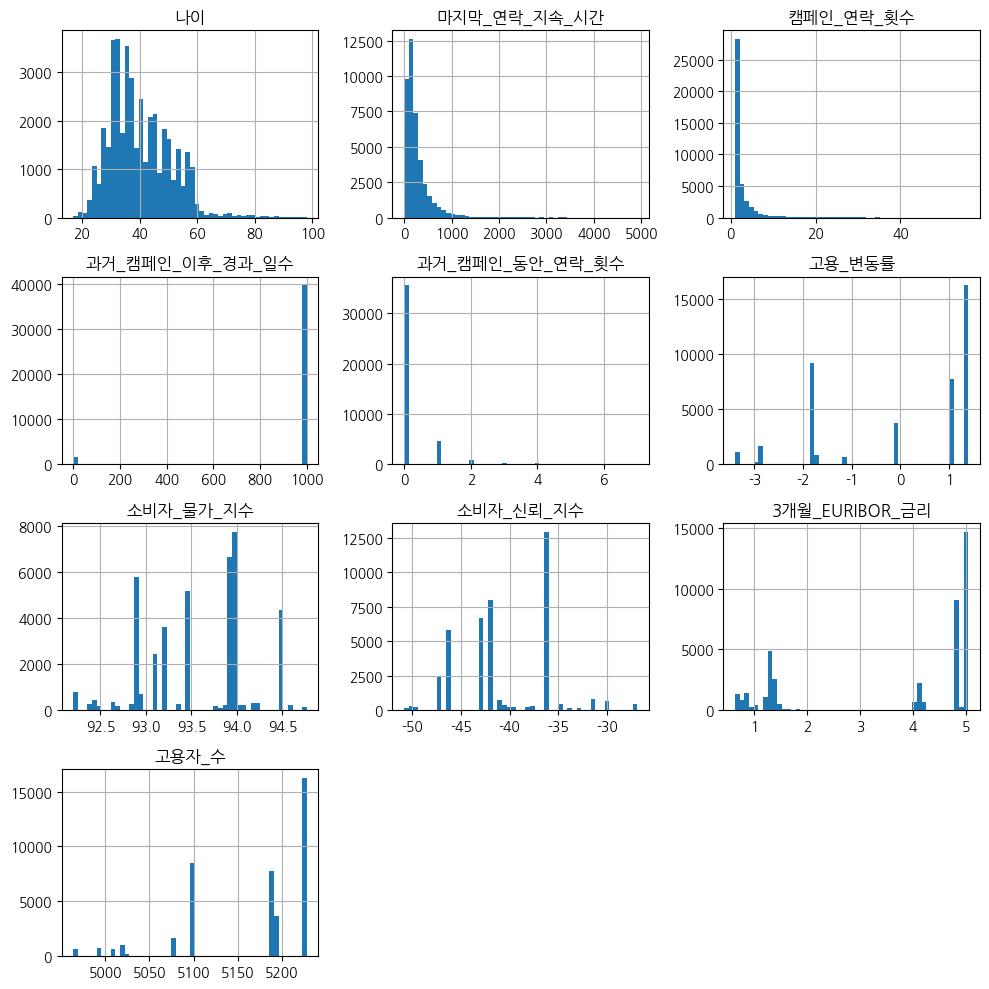

In [12]:
origin_df.hist(bins=50, figsize=(10, 10))
plt.tight_layout()
plt.show()

### 3.1 전처리 전략 정리

- 모델이 학습하여 예측할 대상은 예금 가입 여부 컬럼입니다.

- 위에서 논의된 바와 같이 '마지막 연락 지속 시간'은 삭제합니다.

- one-hot encoding 대상은 다음과 같습니다 :  
    직업, 결혼 여부, 교육 수준, 신용 불량 여부, 주택 대출 여부, 개인 대출 여부, 연락 방식,  
    마지막 연락 월, 마지막 연락 요일, 과거 켐페인 결과  
    위의 컬럼들에게 drop_first=True 설정을 진행하여 다중공선성 발생을 막습니다.

- 과거 캠페인 이후 경과 일수는 연락을 한 적이 없으면 999로 설정되어 있어,  
    이 부분을 분리한 다음 '과거 연락 여부' 컬럼으로 구분하는 처리를 추가합니다.  
    이 처리를 이진 파생 변수 생성이라 합니다.

### 3.2 전처리 기능 구현 및 적용

In [13]:
def preprocess_bank_data(df):
    # 원본 데이터 보호를 위해 데이터프레임 복사
    processed_df = df.copy()
    
    # 삭제 대상 컬럼 제거
    if '마지막_연락_지속_시간' in processed_df.columns:
        processed_df = processed_df.drop(columns=['마지막_연락_지속_시간'])
        
    # 타겟 변수 변환 ('예금 가입 여부': 예 -> 1, 아니오 -> 0)
    if '예금_가입_여부' in processed_df.columns:
        processed_df['예금_가입_여부'] = processed_df['예금_가입_여부'].apply(lambda x: 1 if x == '예' else 0)
        
    # 이진 파생 변수 생성 ('과거 캠페인 이후 경과 일수')
    if '과거_캠페인_이후_경과_일수' in processed_df.columns:
        # 999인지 확인하여 새로운 이진 컬럼 생성 (연락 안함: 0, 연락 함: 1)
        processed_df['과거_연락_여부'] = processed_df['과거_캠페인_이후_경과_일수'].apply(lambda x: 0 if x == 999 else 1)
        # 기존 컬럼의 999 값을 0으로 치환하여 수치 오염 방지
        processed_df['과거_캠페인_이후_경과_일수'] = processed_df['과거_캠페인_이후_경과_일수'].replace(999, 0)

    # One-Hot Encoding 대상 컬럼 처리
    categorical_cols = ['직업', '결혼_여부', '교육_수준', '신용_불량_여부', 
                        '주택_대출_여부', '개인_대출_여부', '연락_방식', 
                        '마지막_연락_월', '마지막_연락_요일', '과거_캠페인_결과']
    
    # 데이터프레임에 실제로 존재하는 컬럼만 필터링
    valid_cat_cols = [col for col in categorical_cols if col in processed_df.columns]
    
    # 원-핫 인코딩 진행 (drop_first=True 설정 하여 다중공선성 방지)
    processed_df = pd.get_dummies(processed_df, columns=valid_cat_cols, drop_first=True)
    
    return processed_df

preprocessed_df = preprocess_bank_data(origin_df)

preprocessed_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 53 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   나이                41188 non-null  int64  
 1   캠페인_연락_횟수         41188 non-null  int64  
 2   과거_캠페인_이후_경과_일수   41188 non-null  int64  
 3   과거_캠페인_동안_연락_횟수   41188 non-null  int64  
 4   고용_변동률            41188 non-null  float64
 5   소비자_물가_지수         41188 non-null  float64
 6   소비자_신뢰_지수         41188 non-null  float64
 7   3개월_EURIBOR_금리    41188 non-null  float64
 8   고용자_수             41188 non-null  float64
 9   예금_가입_여부          41188 non-null  int64  
 10  과거_연락_여부          41188 non-null  int64  
 11  직업_관리자            41188 non-null  bool   
 12  직업_관리직            41188 non-null  bool   
 13  직업_기술자            41188 non-null  bool   
 14  직업_사업가            41188 non-null  bool   
 15  직업_서비스직           41188 non-null  bool   
 16  직업_실업자            41188 non-null  bool   
 17  직업_알

### 3.3 전처리 결과 확인

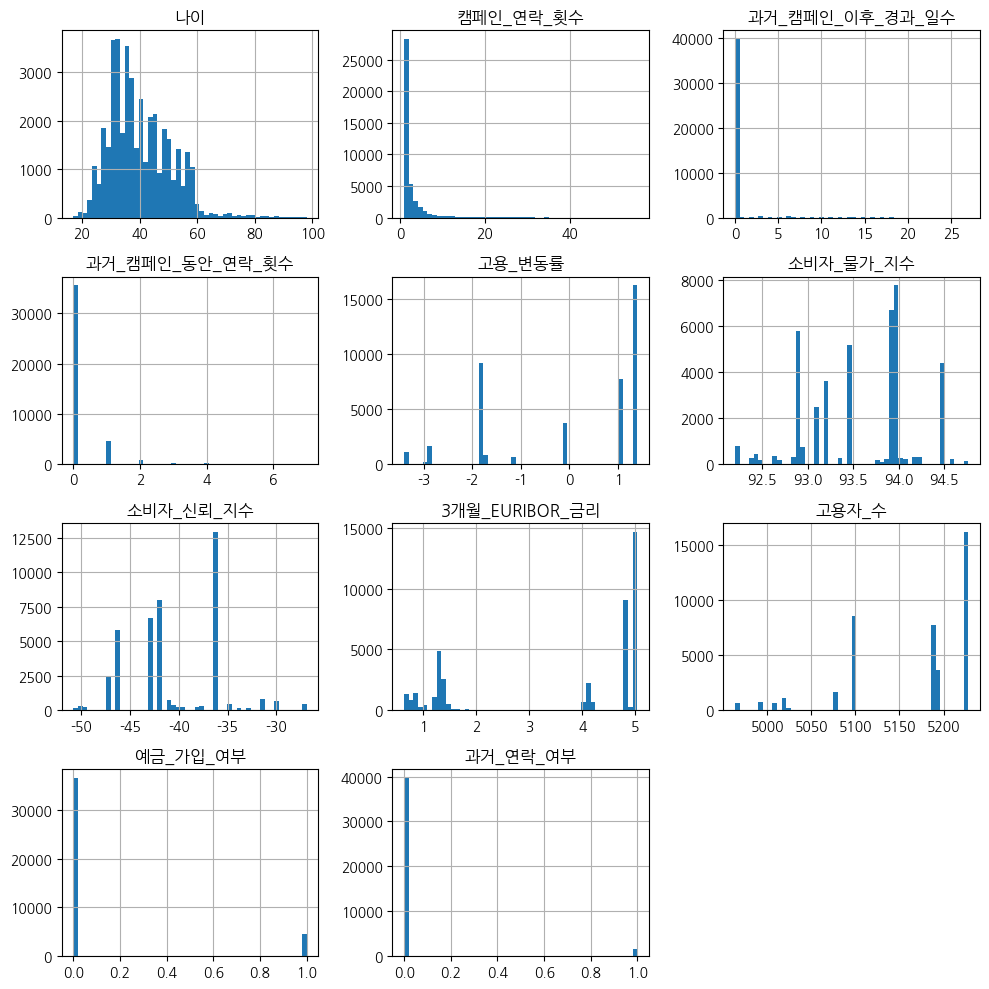

In [14]:
preprocessed_df.hist(bins=50, figsize=(10, 10))
plt.tight_layout()
plt.show()

In [15]:
boolean_cols = preprocessed_df.select_dtypes(include='bool').columns
print("One-Hot Encoding으로 생성된 이진 컬럼들:")
for col in boolean_cols:
    target_column = preprocessed_df[col]
    print(f" - {col}")
    print(f"   True : {target_column.sum()}")
    print(f"   False : {target_column.count() - target_column.sum()}")
    print(f"   True 비율 : {target_column.mean() * 100:.2f}%\n")

One-Hot Encoding으로 생성된 이진 컬럼들:
 - 직업_관리자
   True : 10422
   False : 30766
   True 비율 : 25.30%

 - 직업_관리직
   True : 2924
   False : 38264
   True 비율 : 7.10%

 - 직업_기술자
   True : 6743
   False : 34445
   True 비율 : 16.37%

 - 직업_사업가
   True : 1456
   False : 39732
   True 비율 : 3.54%

 - 직업_서비스직
   True : 3969
   False : 37219
   True 비율 : 9.64%

 - 직업_실업자
   True : 1014
   False : 40174
   True 비율 : 2.46%

 - 직업_알_수_없음
   True : 330
   False : 40858
   True 비율 : 0.80%

 - 직업_육체_노동자
   True : 9254
   False : 31934
   True 비율 : 22.47%

 - 직업_은퇴자
   True : 1720
   False : 39468
   True 비율 : 4.18%

 - 직업_자영업자
   True : 1421
   False : 39767
   True 비율 : 3.45%

 - 직업_학생
   True : 875
   False : 40313
   True 비율 : 2.12%

 - 결혼_여부_미혼
   True : 11568
   False : 29620
   True 비율 : 28.09%

 - 결혼_여부_알_수_없음
   True : 80
   False : 41108
   True 비율 : 0.19%

 - 결혼_여부_이혼
   True : 4612
   False : 36576
   True 비율 : 11.20%

 - 교육_수준_대학_학위
   True : 12168
   False : 29020
   True 비율 : 29.54%

 - 교육_수준_알_수

## 4. 학습 데이터 세트 구축
머신러닝의 학습을 위해서 학습 데이터(X_train, X_test)와  
검증 데이터(y_train, y_test)를 기존의 preprocessed_df 로부터 나눕니다.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = preprocessed_df.drop(columns=['예금_가입_여부'])
y = preprocessed_df['예금_가입_여부']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = ['나이', '캠페인_연락_횟수', '과거_캠페인_동안_연락_횟수', 
                '고용_변동률', '소비자_물가_지수', '소비자_신뢰_지수', 
                '3개월_EURIBOR_금리', '고용자_수']
    
scaler = StandardScaler()
# 훈련 데이터 기준으로 학습(fit) 후 변환(transform)
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# 테스트 데이터는 훈련 데이터 기준으로 변환(transform)만 수행
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

분할이 진행되었으므로 간단히 내용을 살펴 봅니다.

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(32950, 52)
(8238, 52)
(32950,)
(8238,)


## 5. 평가 지표
학습된 모델이 얼마 정도의 성능을 보이는지 측정할 수 있는 지표를 설정합니다.  
훈련된 모델과 위 학습 데이터 세트 구축 항목에서 만들어진 검증 데이터를 넣어  
정밀도, 재현율, F1 점수, ROC-AUC 점수를 출력합니다.  
EDA에서 얻어진 결과에 따라 정확도는 제외합니다.

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# 위 모듈로 수집된 값을 display()로 출력합니다.

다음은 각 지표를 어떻게 평가해야 하는지에 대한 설명입니다.
| 지표명 | 함수명 | 값 | 설명 | 비고 |
| :--- | :--- | :--- | :--- | :--- |
| 정밀도 (Precision) | precision_score | 0 ~ 1 | 모델이 'True'이라고 예측한 데이터 중, 실제 'True' 데이터의 비율입니다. | - |
| 재현율 (Recall) | recall_score | 0 ~ 1 | 실제 데이터를 기준으로 모델이 'True'라고 정확히 찾아낸 비율입니다. | - |
| F1 점수 (F1-Score) | f1_score | 0 ~ 1 | 정밀도와 재현율의 조화 평균(Harmonic Mean)입니다. | 둘 중 하나가 극단적으로 낮아지는 것을 방지하고 모델의 균형 잡힌 성능을 하나의 숫자로 볼 때 가장 유용합니다. |
| ROC-AUC | roc_auc_score | 0 ~ 1 | 모델이 1과 0을 얼마나 잘 구분하는지를 나타내는 지표로, 1에 가까울수록 성능이 우수합니다. | 임계값(Threshold) 변화에 흔들리지 않는 모델의 절대적인 분류 능력을 평가할 때 주로 사용합니다. (0.5=랜덤 수준)|

## 6. 머신러닝 모델 학습 및 평가

### 6.1 모델 선정
지금까지 분석된 사항을 반영하여, 모델은 다음과 같이 정했습니다.
| 모델 | 알고리즘 유형 | SHAP 호환성 | 프로젝트 내 역할
| :--- | :--- | :--- | :--- |
| Logistic Regression | 선형 분류 | LinearExplainer | 성능 평가의 베이스라인 (기준점) |
| Random Forest | 배깅(Bagging) 앙상블 | TreeExplainer | 비선형 패턴 파악 및 과적합 방지 |
| XGBoost | 부스팅(Boosting) 앙상블 | TreeExplainer | GPU 가속 기반의 고성능 예측 |
| LightGBM | 부스팅(Boosting) 앙상블 | TreeExplainer | 불균형 데이터 처리 및 최고 성능 탐색 |

### 6.2 모델 선언
경험적 하이퍼파라미터를 반영하여 모델을 선언하겠습니다.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 경험적 파라미터 반영하여 모델 초기화
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        C=0.1,
        class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        scale_pos_weight=8,
        tree_method='hist',
        device='cuda',
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        is_unbalance=True,
        force_row_wise=True,
        num_leaves=31,
        n_jobs=-1,
        verbose=-1,
        random_state=42
    )
}

### 6.3 초기 모델 학습 및 평가
모델 초기화가 완료되었으므로, 학습 및 평가를 진행하겠습니다.

In [ ]:
results = []
    
print("모델 훈련 및 평가 시작")
print("-" * 50)

# 모델 훈련 및 평가 루프
for model_name, model in models.items():
    print(f"[{model_name}] 학습 중...")
    
    # 모델 학습
    model.fit(X_train, y_train)
    
    # 모델 예측
    y_pred = model.predict(X_test)
    
    # 모델 예측 확률 (ROC-AUC용, 확률의 1번 인덱스가 '가입(1)'일 확률)
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_pred_proba = model.decision_function(X_test)
        
    # 평가 지표 계산
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    # 결과 저장
    results.append({
        "Model": model_name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })
    
# 결과를 DataFrame으로 변환 및 F1-Score 기준 내림차순 정렬
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("-" * 50)
print("모든 학습 및 평가 완료")
display(results_df)

모델 훈련 및 평가 시작
--------------------------------------------------
[Logistic Regression] 학습 중...
[Random Forest] 학습 중...
[XGBoost] 학습 중...
[LightGBM] 학습 중...
--------------------------------------------------
모든 학습 및 평가 완료


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.4016,0.5850,0.4763,0.7902
1,LightGBM,0.3869,0.5947,0.4688,0.7811
2,XGBoost,0.3777,0.5829,0.4584,0.7731
3,Logistic Regression,0.3480,0.6096,0.4431,0.7816


1. 로지스틱 회귀(Logistic Regression)의 예상 밖 결과  
데이터 전처리를 통해 선형적인 패턴이 명확하게 드러났다는 증거로 볼 수 있습니다.  
특히 실제 가입자를 찾아내는 능력을 의미하는 재현율(Recall)은 0.6096으로 4개 모델 중 1위를 차지했습니다.  

2. 랜덤 포레스트(Random Forest)의 1위  
결정 트리 기반의 앙상블 모델인 랜덤 포레스트가 F1-Score(0.4763)와 ROC-AUC(0.7902)에서 1위를 차지했습니다.  
랜덤 포레스트는 본래 파라미터에 크게 민감하지 않고 기본 설정만으로도 데이터의 비선형적인 패턴을 안정적으로 잡아내는 특성이 있는데,  
이 강점이 불균형 데이터셋에서 발휘된 것으로 보입니다.

3. 부스팅 모델(LightGBM, XGBoost)의 부진  
현재 설정된 파라미터가 '경험적 추천값'일 뿐 이 데이터셋에 완벽히 피팅되지 않았기 때문으로 보입니다.

### 6.4 Optuna 튜닝 모델 학습 및 평가
Optuna는 베이지안 최적화(Bayesian Optimization) 알고리즘을 사용하여,  
무작위로 파라미터를 잡아보는 기존 방식(Grid Search)보다 훨씬 빠르고 정확하게 최적값을 찾아냅니다.

In [42]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
import xgboost as xgb
import lightgbm as lgb

# Optuna 로깅 출력을 경고(Warning) 레벨로 설정
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optimize_and_evaluate_all(X_train, y_train, X_test, y_test):
    # F1-Score를 최적화 목표 지표로 설정 (불균형 데이터 핵심 지표)
    f1_scorer = make_scorer(f1_score)
    best_models = {}
    tuning_results = []

    print("Optuna 자동 하이퍼파라미터 탐색(3-Fold 교차 검증 포함)을 시작")
    print("-" * 50)

    # Logistic Regression 튜닝 메서드
    def optimize_LogisticRegression(trial):
        C = trial.suggest_float('C', 0.01, 10.0, log=True)
        model = LogisticRegression(class_weight='balanced', max_iter=2000, C=C, random_state=42)
        score = cross_val_score(model, X_train, y_train, cv=3, scoring=f1_scorer, n_jobs=-1).mean()
        return score
    
    print("Logistic Regression 튜닝 시작")
    study_lr = optuna.create_study(direction='maximize')
    study_lr.optimize(optimize_LogisticRegression, n_trials=20)
    best_lr = LogisticRegression(class_weight='balanced', max_iter=2000, C=study_lr.best_params['C'], random_state=42)
    best_models['Logistic Regression'] = best_lr

    # Random Forest 튜닝 메서드
    def optimize_RandomForest(trial):
        max_depth = trial.suggest_int('max_depth', 5, 20)
        min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
        model = RandomForestClassifier(
            n_estimators=100, max_depth=max_depth, min_samples_split=min_samples_split,
            class_weight='balanced_subsample', n_jobs=-1, random_state=42
        )
        score = cross_val_score(model, X_train, y_train, cv=3, scoring=f1_scorer, n_jobs=-1).mean()
        return score

    print("Random Forest 튜닝 시작")
    study_rf = optuna.create_study(direction='maximize')
    study_rf.optimize(optimize_RandomForest, n_trials=20)
    best_rf = RandomForestClassifier(
        n_estimators=300, max_depth=study_rf.best_params['max_depth'], 
        min_samples_split=study_rf.best_params['min_samples_split'],
        class_weight='balanced_subsample', n_jobs=-1, random_state=42
    )
    best_models['Random Forest'] = best_rf

    # XGBoost 튜닝 메서드 (GPU 가속!)
    def optimize_XGBoost(trial):
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)
        max_depth = trial.suggest_int('max_depth', 3, 9)
        model = xgb.XGBClassifier(
            scale_pos_weight=8, learning_rate=learning_rate, max_depth=max_depth,
            n_estimators=150, tree_method='hist', device='cuda', random_state=42, eval_metric='logloss'
        )
        score = cross_val_score(model, X_train, y_train, cv=3, scoring=f1_scorer).mean()
        return score

    print("XGBoost GPU 가속 튜닝 시작")
    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(optimize_XGBoost, n_trials=30)
    best_xgb = xgb.XGBClassifier(
        scale_pos_weight=8, learning_rate=study_xgb.best_params['learning_rate'], 
        max_depth=study_xgb.best_params['max_depth'], n_estimators=500, 
        tree_method='hist', device='cuda', random_state=42, eval_metric='logloss'
    )
    best_models['XGBoost'] = best_xgb

    # LightGBM 튜닝 메서드
    def optimize_LightGBM(trial):
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)
        num_leaves = trial.suggest_int('num_leaves', 20, 60)
        model = lgb.LGBMClassifier(
            is_unbalance=True, learning_rate=learning_rate, num_leaves=num_leaves,
            n_estimators=150, n_jobs=-1, random_state=42, verbose=-1
        )
        score = cross_val_score(model, X_train, y_train, cv=3, scoring=f1_scorer, n_jobs=-1).mean()
        return score

    print("LightGBM 튜닝 시작")
    study_lgb = optuna.create_study(direction='maximize')
    study_lgb.optimize(optimize_LightGBM, n_trials=30)
    best_lgb = lgb.LGBMClassifier(
        is_unbalance=True, learning_rate=study_lgb.best_params['learning_rate'], 
        num_leaves=study_lgb.best_params['num_leaves'], n_estimators=500, 
        n_jobs=-1, random_state=42, verbose=-1
    )
    best_models['LightGBM'] = best_lgb

    print("-" * 50)
    print("모든 튜닝 완료! 최종 평가 진행")
    
    # 최종 평가 진행
    for name, model in best_models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_pred_proba = model.decision_function(X_test)
            
        tuning_results.append({
            "Model (Tuned)": name,
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "F1-Score": round(f1_score(y_test, y_pred), 4),
            "ROC-AUC": round(roc_auc_score(y_test, y_pred_proba), 4)
        })

    tuned_df = pd.DataFrame(tuning_results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
    display(tuned_df)
    
    return best_models, tuned_df

best_tuned_models, final_benchmark_df = optimize_and_evaluate_all(X_train, y_train, X_test, y_test)

Optuna 자동 하이퍼파라미터 탐색(3-Fold 교차 검증 포함)을 시작
--------------------------------------------------
Logistic Regression 튜닝 시작
Random Forest 튜닝 시작
XGBoost GPU 가속 튜닝 시작
LightGBM 튜닝 시작
--------------------------------------------------
모든 튜닝 완료! 최종 평가 진행


,Model (Tuned),Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.4396,0.5487,0.4881,0.7885
1,LightGBM,0.3917,0.6075,0.4763,0.7944
2,XGBoost,0.3913,0.5968,0.4727,0.7872
3,Logistic Regression,0.3514,0.6096,0.4458,0.7814


- 1위는 계속해서 Random Forest : 마케팅 캠페인에서는 타겟팅의 정밀도(Precision)와 재현율(Recall)의  
    균형을 맞추는 것이 가장 중요하기 때문에, Random Forest를 최종 모델로 선정하였습니다.  
    특히 정밀도(Precision)가 0.4016에서 0.4396으로 크게 최적화되어,  
    '마케팅 성공 확률이 높은 진짜 잠재 고객'을 잘 골라낼 수 있는 예측 모델이 될 것이라는 기대를 가지게 합니다.

- 부스팅 모델이 언제나 최선은 아니다: ROC-AUC 지표(0.7944)에서 LightGBM이 앞서는 모습을 보였지만  
    종합적인 성능에서 Random Forest 를 이기지는 못했습니다.

### 6.5 Optuna 로 최적화된 하이퍼파라미터 출력

In [43]:
best_tuned_model = best_tuned_models['Random Forest']
best_params = best_tuned_model.get_params()

print("최적화된 Random Forest 모델의 주요 하이퍼파라미터:")
for key, value in best_params.items():
    print(f"{key:<20}: {value}")

최적화된 Random Forest 모델의 주요 하이퍼파라미터:
bootstrap           : True
ccp_alpha           : 0.0
class_weight        : balanced_subsample
criterion           : gini
max_depth           : 15
max_features        : sqrt
max_leaf_nodes      : None
max_samples         : None
min_impurity_decrease: 0.0
min_samples_leaf    : 1
min_samples_split   : 7
min_weight_fraction_leaf: 0.0
monotonic_cst       : None
n_estimators        : 300
n_jobs              : -1
oob_score           : False
random_state        : 42
verbose             : 0
warm_start          : False


## 7. 머신러닝 모델 분석
이제 최적화된 모델이 데이터를 어떻게 예측하게 되었는지에 대한  
여러 평가 지표들을 모델이 판단한 중요도와 SHAP을 통해 살펴보고 분석하겠습니다.  
SHAP를 모든 데이터에 대해 분석을 진행하면 시간이 많이 걸리기 때문에  
1000개의 데이터를 무작위 샘플링하여 분석을 진행하도록 하겠습니다.

### 7.1 Random Forest Feature Importance 출력

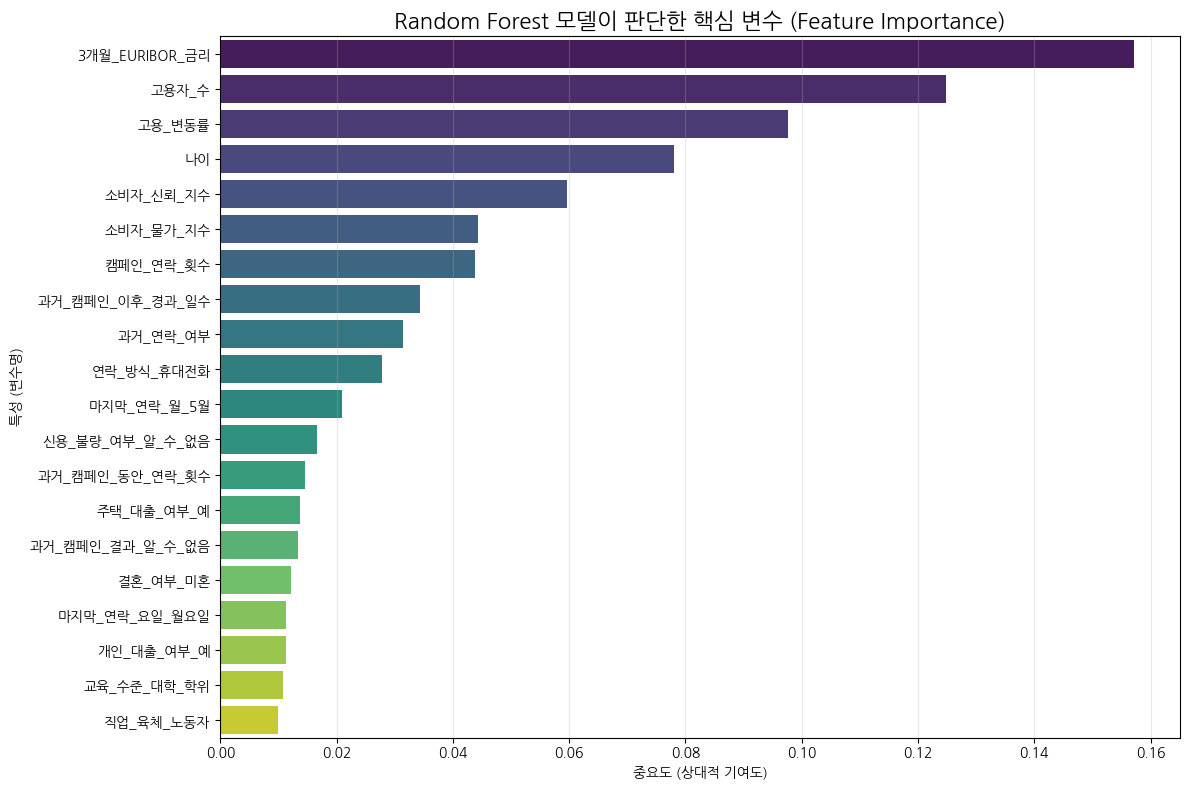

In [51]:
importances = best_tuned_model.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), hue='Feature', palette='viridis', legend=False)

plt.title('Random Forest 모델이 판단한 핵심 변수 (Feature Importance)', fontsize=16)
plt.xlabel('중요도 (상대적 기여도)')
plt.ylabel('특성 (변수명)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

그래프는 Random Forest 모델이 판단한 핵심 변수를 중요도가 높은 순으로 출력한 그래프입니다.  

- 3개월 EURIBO 금리, 고용자 수, 고용 변동률 같은 거시 경제 지표가 아주 큰 비중을 차지하는 것으로 확인됩니다.

- 나이가 EDA 로 예상했던 것보다 큰 비중을 차지합니다. 아마도 값의 분포가 넓고 다양해서 그런 것으로 보입니다.

- 소비자 신뢰 지수, 소비자 물가 지수 같은 지표는 거시 경제 지표와 밀접한 연관이 있기 때문에 연동된 비중을 차지하는 것으로 보입니다..

- 캠페인 연락 횟수가 큰 비중을 차지합니다. 연락을 많이 하는 것이 좋은 것인지는 명확하지 않습니다.

- 과거 캠페인 연락 유무가 유의미한 비중을 차지하고 있습니다.

- EDA에서 분석된 것처럼 휴대전화는 중요도가 높습니다.

### 7.2 SHAP 분석

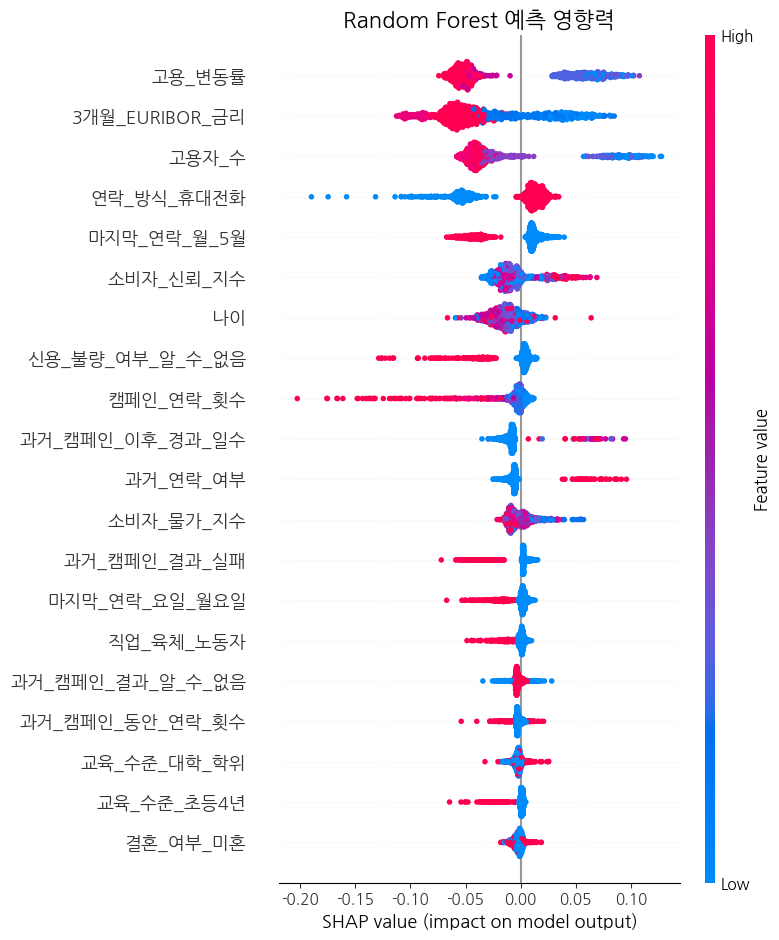

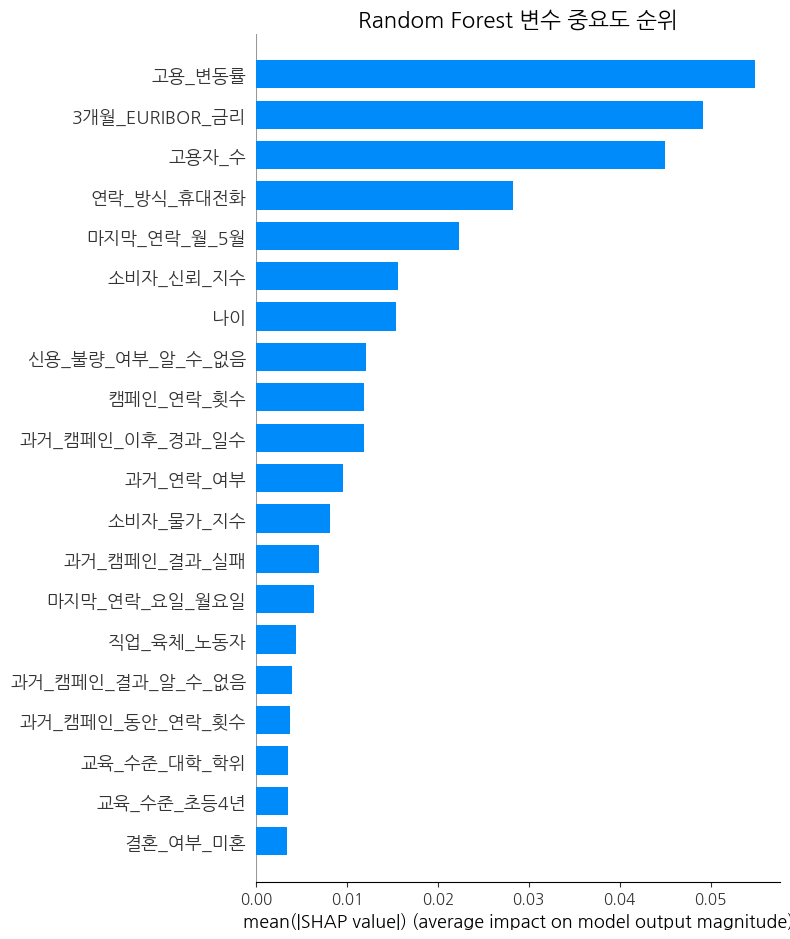

In [29]:
import shap

def run_shap_analysis_fixed(best_rf_model, X_test):
    explainer = shap.TreeExplainer(best_rf_model)
    
    # 빠른 분석을 위해 1,000개 무작위 샘플링
    X_test_sampled = shap.sample(X_test, 1000, random_state=42)
    
    shap_obj = explainer(X_test_sampled)
    
    # 차원(Dimension) 방어 코드: 3차원(샘플수, 변수수, 클래스수)일 경우 클래스 1(가입)만 추출
    if len(shap_obj.shape) == 3:
        shap_values_class_1 = shap_obj[:, :, 1]
    else:
        shap_values_class_1 = shap_obj
    
    # 요약 플롯 (Dot)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_class_1, X_test_sampled, plot_type="dot", show=False)
    plt.title("Random Forest 예측 영향력", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # 중요도 바 차트 (Bar)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_class_1, X_test_sampled, plot_type="bar", show=False)
    plt.title("Random Forest 변수 중요도 순위", fontsize=16)
    plt.tight_layout()
    plt.show()

run_shap_analysis_fixed(best_tuned_model, X_test)

그래프는 SHAP 으로 분석된 변수 중요도를 개별적인 산점도와 합산된 막대 그래프로 표현한 것입니다.  
이제 이것을 분석하자면,  

- 경제 지표의 영향력은 절대적이다 : 고용 변동률, 3개월 EURIBO 금리, 고용자 수 지표가 다른 지표들과는 다르게  
    0.00을 기준으로 아주 명확하게 왼쪽-가입확률 감소 / 오른쪽-가입확률 증가로 나뉘어 있는 것을 확인할 수 있습니다. 
    즉 언급된 3개의 지표가 증가할때는 가입확률이 감소하고, 지표가 감소할때는 가입확률이 증가한다는 것을 명확히 보여주고 있습니다.

- EDA로 분석하여 가설을 세웠던 것처럼, 휴대전화를 통한 마케팅은 유선전화를 통하는 것보다 아주 효과적임이 증명되었습니다.  

- 풀리지 않는 5월의 문제 : 정확한 이유는 특정할 수 없지만, 지표상 5월에는 마케팅 효율이 급감하는 것이 확인되었습니다.

- 신용 불량을 숨기는 사람은 고객이 될 확률이 낮다는 것이 명확히 확인됩니다.

- 스팸 전화를 조심해야 한다 : 자주 캠페인 전화를 받을수록 명확하게 가입 거절 의사가 강해지는 것을 확인할 수 있습니다.

- 성공한 과거는 성공적인 현재를 불러온다 : 과거에 연락을 받았던 고객들은 다시 권유받았을 때  
    EDA 분석처럼 가입할 확률이 높아짐이 확인됩니다. 다만, 스팸 전화로 인식되지 않도록 권유 시간 간격을 확실하게 둘 필요가 있습니다.

## 8. 결론 : 마케팅 전략 보고

### 8.1 경제 지표에 따른 타이밍 전략
이번 분석에서 가장 핵심적인 발견은 고객 개인의 프로필보다 '경제 지표'가 캠페인의 성패를 훨씬 더 강력하게 좌우한다는 점입니다.  
고용 시장 지표(고용자 수, 고용 변동률)가 하락하고 3개월 EURIBOR 금리가 낮아지는 등 시장 불안정성이 커질 때,  
고객들의 정기 예금(안전 자산) 가입 확률이 급증합니다.  
따라서 경제 지표가 둔화될 때를 캠페인의 '골든타임'으로 설정하고 예산을 집중 투입해야 합니다

### 8.2 마케팅 비수기 5월
데이터상 5월에 연락을 취한 고객들의 가입 확률이 극단적으로 하락하는 뚜렷한 군집이 확인되었습니다.  
5월 중에는 마케팅 운영을 축소하고 기존 VIP 고객 관리나 인바운드 대응으로 리소스를 전환하는 것이 유리합니다.

### 8.3 휴대전화 중심의 캠페인 전개
유선 전화(집/회사)보다는 '휴대전화' 번호가 확보된 고객을 최우선 컨택 타겟으로 할당하여  
상담 연결율과 전환율을 동시에 끌어올려야 합니다.  
다만, 동일한 캠페인 기간 내에 한 고객에게 전화를 거는 횟수가 늘어날수록 가입 확률은 오히려 급감하는 '스팸전화'효과가 입증되었습니다.  
따라서 고객에게 전화를 거는 최대 횟수를 1 ~ 2회로 제한하는 정책을 반영하여야 합니다.  
또한 모든 조사에서 유의미하게 확인된 과거 캠페인 이후 가입률 상승을 염두하여  
캠페인을 진행했던 고객의 사실 여부를 잘 기록하여 다음 캠페인에서 적극적으로 활용 할수 있도록 해야 합니다.

### 8.4 가려진 신용 불량 여부는 가입여부를 불투명하게 합니다
신용 불량 여부에 대한 정보를 제공하지 않은 고객은 실질적인 예치 여력이 없는 허수 고객일 확률이 높으므로  
타겟 리스트에서 과감히 후순위로 배제하여 마케팅 효율을 최적화해야 합니다.